<a href="https://colab.research.google.com/github/VasilisPapageorgiou/Amortization-of-Risk-Indicators/blob/main/Amortization_Exp5_1_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive

1 = RESUME latest run
2 = START NEW run
Choose 1 or 2: 1

ROOT: /content/drive/MyDrive/StatisticalLearning/Experiment_5_2A_R10000/run_20260824_161227
R = 10000
train_N = (40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300, 320, 340, 360, 380, 400)
interp_N = (60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 360, 390)
TRAIN_R10000: full cache (10,000)
VALIDATION: full cache (500)
TEST_SEEN: full cache (500)
TEST_INTERP: full cache (450)

Train=10,000 | Val=500 | Seen=500 | Interp=450
FINAL R10000 model loaded | best epoch=488

FINAL TABLE — R=10,000
                 Metric   Median       Q1       Q3      P95
                     E2 0.005107 0.001486 0.008535 0.017010
                   Erho 0.007565 0.001786 0.013316 0.025289
                  Eover 0.000576 0.000001 0.003338 0.010164
                    DKL 0.001213 0.000308 0.002927 0.007363
  Relative error E(tau) 0.009958 0.003851 0.022600 0.107658
Relative error Var(tau) 0.015533 0.006591 0.

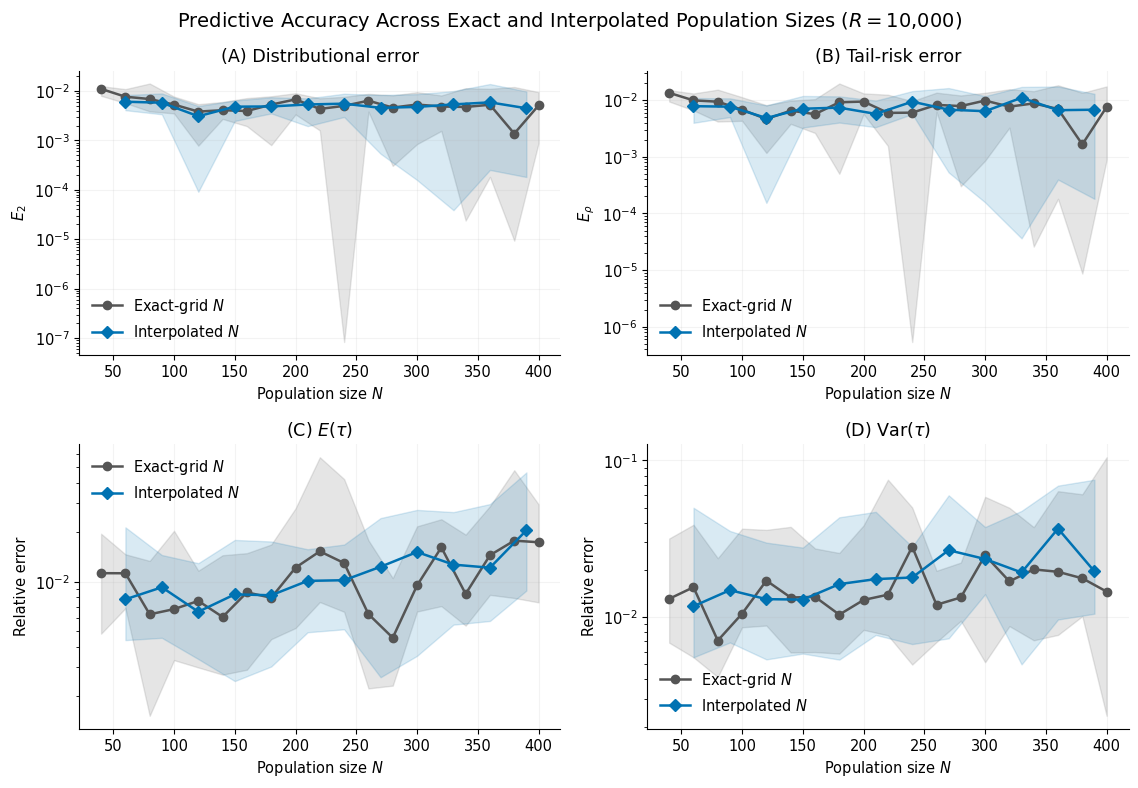


SECTION 5.2-A COMPLETE
R = 10000
train_N = (40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300, 320, 340, 360, 380, 400)
interp_N = (60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 360, 390)

Best epoch: 488
Stopped epoch: 500

Table:
/content/drive/MyDrive/StatisticalLearning/Experiment_5_2A_R10000/run_20260824_161227/results/table_5_2A_R10000.csv

Figure:
/content/drive/MyDrive/StatisticalLearning/Experiment_5_2A_R10000/run_20260824_161227/results/figure_5_2A_R10000.pdf

Diagnostic:
/content/drive/MyDrive/StatisticalLearning/Experiment_5_2A_R10000/run_20260824_161227/results/auxiliary_true_interpolation_R10000.csv

Disconnect -> rerun same cell -> choose 1 = RESUME.


In [3]:
# =====================================================================================
# SECTION 5.2 — EXACT-TEACHER ACCURACY / POPULATION-SIZE TRANSFER
# R = 10,000 | manuscript grids unchanged | resumable | median + IQR
# =====================================================================================

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import os, json, math, pickle, random, hashlib, time
from dataclasses import dataclass, asdict
from datetime import datetime
from functools import lru_cache
from pathlib import Path
from typing import Tuple

os.environ["OMP_NUM_THREADS"]="1"
os.environ["OPENBLAS_NUM_THREADS"]="1"
os.environ["MKL_NUM_THREADS"]="1"

import numpy as np
import pandas as pd
from scipy import sparse
from scipy.sparse.linalg import splu
from scipy.stats import qmc
from joblib import Parallel, delayed
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


# =====================================================================================
# 1. CONFIG — N GRIDS UNCHANGED
# =====================================================================================

@dataclass
class Config:
    seed:int=20260820

    beta:Tuple[float,float]=(.30,1.50)
    gamma:Tuple[float,float]=(.20,1.00)
    omega:Tuple[float,float]=(.02,.50)
    frac:Tuple[float,float]=(.02,.20)

    # EXACTLY AS IN YOUR CODE
    train_N:Tuple[int,...]=tuple([
        40,60,80,100,120,140,160,180,200,220,
        240,260,280,300,320,340,360,380,400
    ])

    # EXACTLY AS IN YOUR CODE
    interp_N:Tuple[int,...]=tuple([
        60,90,120,150,180,210,240,270,300,330,360,390
    ])

    n_train:int=10_000
    n_val:int=500
    n_test_seen:int=500
    n_test_interp:int=450

    width:int=128
    depth:int=3
    batch:int=64
    epochs:int=500

    lr:float=1e-3
    wd:float=1e-6

    lambda_rho:float=1.
    lambda_tau:float=.02

    patience:int=20
    scheduler_patience:int=15
    delta:float=1e-6
    clip:float=5.

    prob_tol:float=1e-10
    var_tol:float=1e-8
    kl_eps:float=1e-12
    refine:int=3


cfg=Config()

N_SCALE=max(cfg.train_N)
EXACT_CHUNK=50
CHECKPOINT_EVERY=5


# =====================================================================================
# 2. RESUME / START NEW
# =====================================================================================

CODE_VERSION="5.2A_R10000_v1"

SCI={
    "code_version":CODE_VERSION,
    "config":asdict(cfg),
    "summary":"median+IQR"
}

SIG=hashlib.sha256(
    json.dumps(SCI,sort_keys=True,default=str).encode()
).hexdigest()[:16]

BASE=Path(
    "/content/drive/MyDrive/StatisticalLearning/"
    "Experiment_5_2A_R10000"
)
BASE.mkdir(parents=True,exist_ok=True)

print("\n1 = RESUME latest run")
print("2 = START NEW run")
mode=input("Choose 1 or 2: ").strip()

LATEST=BASE/"latest_run.txt"

if mode=="2":
    ROOT=BASE/f"run_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    ROOT.mkdir()

    with open(ROOT/"manifest.pkl","wb") as f:
        pickle.dump(
            {"signature":SIG,"science":SCI},
            f,pickle.HIGHEST_PROTOCOL
        )

    LATEST.write_text(ROOT.name)

elif mode=="1":
    if not LATEST.exists():
        raise RuntimeError("No previous run.")

    ROOT=BASE/LATEST.read_text().strip()

    with open(ROOT/"manifest.pkl","rb") as f:
        old=pickle.load(f)

    if old["signature"]!=SIG:
        raise RuntimeError(
            "Scientific specification changed. Choose START NEW."
        )

else:
    raise RuntimeError("Choose 1 or 2.")


CACHE=ROOT/"cache"
EXACT=CACHE/"exact"
MODELS=CACHE/"models"
CKPT=CACHE/"checkpoints"
OUT=ROOT/"results"

for d in (CACHE,EXACT,MODELS,CKPT,OUT):
    d.mkdir(parents=True,exist_ok=True)

print("\nROOT:",ROOT)
print("R =",cfg.n_train)
print("train_N =",cfg.train_N)
print("interp_N =",cfg.interp_N)


# =====================================================================================
# 3. UTILITIES
# =====================================================================================

def apickle(x,p):
    p=Path(p)
    q=p.with_suffix(p.suffix+".tmp")
    with open(q,"wb") as f:
        pickle.dump(x,f,pickle.HIGHEST_PROTOCOL)
    os.replace(q,p)

def atorch(x,p):
    p=Path(p)
    q=p.with_suffix(p.suffix+".tmp")
    torch.save(x,q)
    os.replace(q,p)

def pload(p):
    try:
        with open(p,"rb") as f:
            return pickle.load(f)
    except Exception:
        return None

def seed_all(s):
    random.seed(s)
    np.random.seed(s)
    torch.manual_seed(s)

seed_all(cfg.seed)

CPU=os.cpu_count() or 1
N_EXACT=max(1,min(2,CPU))
torch.set_num_threads(max(1,min(8,CPU)))

try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass


# =====================================================================================
# 4. EXACT TEACHER
# =====================================================================================

@dataclass
class Rec:
    b:float; g:float; w:float
    N:int; i0:int
    p:np.ndarray
    mt:float; vt:float
    tv:bool


@lru_cache(None)
def topo(N):
    st=[(s,i) for i in range(1,N+1) for s in range(N-i+1)]
    ix={x:j for j,x in enumerate(st)}
    M=len(st)

    ir=[]; ic=[]; ib=[]
    rr=[]; rc=[]; rb=[]
    wr=[]; wc=[]; wb=[]
    db=np.zeros(M); dg=np.zeros(M); dw=np.zeros(M); qb=np.zeros(M)

    for j,(s,i) in enumerate(st):
        r=N-s-i

        if s:
            ir.append(j); ic.append(ix[(s-1,i+1)])
            z=s*i/N
            ib.append(z); db[j]=z

        dg[j]=i

        if i==1:
            qb[j]=i
        else:
            rr.append(j); rc.append(ix[(s,i-1)]); rb.append(i)

        if r:
            wr.append(j); wc.append(ix[(s+1,i)])
            wb.append(r); dw[j]=r

    A=lambda x,d=float:np.asarray(x,dtype=d)

    return (
        ix,M,
        A(ir,int),A(ic,int),A(ib),
        A(rr,int),A(rc,int),A(rb),
        A(wr,int),A(wc,int),A(wb),
        db,dg,dw,qb
    )


def refined(A,lu,b,T=False):
    b=np.asarray(b,float)
    x=lu.solve(b,trans="T" if T else "N")

    for _ in range(cfg.refine):
        r=b-(A.T@x if T else A@x)

        if not np.all(np.isfinite(r)):
            break

        if (
            np.linalg.norm(r,np.inf)
            /
            max(np.linalg.norm(b,np.inf),1.)
            <1e-11
        ):
            break

        x+=lu.solve(r,trans="T" if T else "N")

    return np.asarray(x,float)


def exact_target(b,g,w,N,i0):
    (
        ix,M,ir,ic,ib,rr,rc,rb,
        wr,wc,wb,db,dg,dw,qb
    )=topo(N)

    rows=np.r_[ir,rr,wr,np.arange(M)]
    cols=np.r_[ic,rc,wc,np.arange(M)]

    T=sparse.coo_matrix(
        (
            np.r_[b*ib,g*rb,w*wb,-(b*db+g*dg+w*dw)],
            (rows,cols)
        ),
        shape=(M,M)
    ).tocsc()

    D1=sparse.coo_matrix(
        (b*ib,(ir,ic)),
        shape=(M,M)
    ).tocsc()

    D0=(T-D1).tocsc()
    q=g*qb
    initial=ix[(N-i0,i0)]

    # -------------------------------------------------------------------------
    # Infection-count distribution
    # -------------------------------------------------------------------------

    A0=(-D0).tocsc()
    lu0=splu(A0,permc_spec="COLAMD")
    bvec=refined(A0,lu0,q)

    v=np.zeros(M)
    v[initial]=1.

    p=np.zeros(N+2)
    D1T=D1.T.tocsr()

    for k in range(N+1):
        p[k]=v@bvec
        v=np.asarray(
            D1T@refined(A0,lu0,v,T=True)
        ).ravel()

    p[-1]=v.sum()
    p[np.abs(p)<cfg.prob_tol]=0.

    if (
        not np.all(np.isfinite(p))
        or p.min() < -cfg.prob_tol
    ):
        raise RuntimeError("Invalid PMF.")

    p=np.maximum(p,0.)
    mass=p.sum()

    if (
        not np.isfinite(mass)
        or abs(mass-1.)>1e-5
    ):
        raise RuntimeError(f"Invalid mass={mass}.")

    p/=mass

    # -------------------------------------------------------------------------
    # Extinction-time moments
    # -------------------------------------------------------------------------

    A=(-T).tocsc()
    mt=vt=np.nan
    valid=False

    for ordering in ("COLAMD","MMD_AT_PLUS_A"):
        try:
            d=np.abs(A.diagonal())
            scale=1./np.maximum(d,np.finfo(float).tiny)

            lu=splu(
                (sparse.diags(scale)@A).tocsc(),
                permc_spec=ordering
            )

            def solve(rhs):
                rhs=np.asarray(rhs,float)
                x=lu.solve(scale*rhs)

                for _ in range(cfg.refine):
                    r=rhs-A@x

                    if not np.all(np.isfinite(r)):
                        break

                    if (
                        np.linalg.norm(r,np.inf)
                        /
                        max(np.linalg.norm(rhs,np.inf),1.)
                        <1e-11
                    ):
                        break

                    x+=lu.solve(scale*r)

                return np.asarray(x,float)

            m1=solve(np.ones(M))
            mean=float(m1[initial])

            if (
                not np.all(np.isfinite(m1))
                or mean<=0
            ):
                raise ArithmeticError

            m2=solve(2*m1)
            second=float(m2[initial])

            if (
                not np.all(np.isfinite(m2))
                or second<=0
            ):
                raise ArithmeticError

            raw=np.longdouble(second)-np.longdouble(mean)**2
            tol=cfg.var_tol*max(abs(second),mean*mean,1.)

            if np.isfinite(raw) and raw>=-tol:
                var=max(float(raw),0.)
            else:
                C=T.tocoo()
                off=C.row!=C.col

                source=np.bincount(
                    C.row[off],
                    weights=C.data[off]*(
                        m1[C.col[off]]-m1[C.row[off]]
                    )**2,
                    minlength=M
                ).astype(float)

                source+=q*m1*m1

                var=float(
                    solve(np.maximum(source,0.))[initial]
                )

            if (
                not np.isfinite(var)
                or var<0
            ):
                raise ArithmeticError

            mt,vt,valid=mean,var,True
            break

        except Exception:
            pass

    return Rec(b,g,w,N,i0,p,mt,vt,valid)


# =====================================================================================
# 5. DESIGN + EXACT CACHE
# =====================================================================================

def design(n,Ns,seed):
    U=qmc.LatinHypercube(4,seed=seed).random(n)
    S=lambda x,a:a[0]+(a[1]-a[0])*x

    b=S(U[:,0],cfg.beta)
    g=S(U[:,1],cfg.gamma)
    w=S(U[:,2],cfg.omega)
    f=S(U[:,3],cfg.frac)

    Nv=np.tile(np.asarray(Ns),math.ceil(n/len(Ns)))[:n]

    rng=np.random.default_rng(seed+991)
    rng.shuffle(Nv)

    i0=np.asarray([
        int(np.clip(round(f[j]*Nv[j]),2,Nv[j]))
        for j in range(n)
    ])

    for N in Ns:
        z=np.where(Nv==N)[0]

        if len(z):
            k=max(1,round(.25*len(z)))
            i0[rng.choice(z,k,replace=False)]=1

    return [
        (
            float(b[j]),float(g[j]),float(w[j]),
            int(Nv[j]),int(i0[j])
        )
        for j in range(n)
    ]


def match(rec,cfgs,tol=1e-12):
    if rec is None or len(rec)!=len(cfgs):
        return False

    return all(
        abs(r.b-x[0])<=tol and
        abs(r.g-x[1])<=tol and
        abs(r.w-x[2])<=tol and
        r.N==x[3] and
        r.i0==x[4]
        for r,x in zip(rec,cfgs)
    )


def exact_one(j,x):
    return j,exact_target(*x)


def exact_set(name,cfgs):
    full=EXACT/f"{name}_full.pkl"
    z=pload(full)

    if match(z,cfgs):
        print(f"{name}: full cache ({len(z):,})")
        return z

    folder=EXACT/name
    folder.mkdir(parents=True,exist_ok=True)

    ans=[]

    for s in range(0,len(cfgs),EXACT_CHUNK):
        e=min(s+EXACT_CHUNK,len(cfgs))
        cc=cfgs[s:e]

        f=folder/f"chunk_{s:05d}_{e:05d}.pkl"
        part=pload(f)

        if not match(part,cc):
            jobs=list(enumerate(cc))
            jobs.sort(key=lambda z:z[1][3],reverse=True)

            t0=time.perf_counter()

            out=Parallel(
                n_jobs=N_EXACT,
                backend="threading"
            )(
                delayed(exact_one)(j,x)
                for j,x in jobs
            )

            out.sort(key=lambda z:z[0])
            part=[r for _,r in out]

            apickle(part,f)

            print(
                f"{name} {s:5d}:{e:5d} | "
                f"{time.perf_counter()-t0:.1f}s"
            )

        else:
            print(f"{name} {s:5d}:{e:5d} | cache")

        ans.extend(part)

    if not match(ans,cfgs):
        raise RuntimeError(f"{name}: cache/design mismatch.")

    apickle(ans,full)
    return ans


# =====================================================================================
# 6. DATASETS
# =====================================================================================

train=exact_set(
    "TRAIN_R10000",
    design(cfg.n_train,cfg.train_N,cfg.seed+1)
)

val=exact_set(
    "VALIDATION",
    design(cfg.n_val,cfg.train_N,cfg.seed+2)
)

seen=exact_set(
    "TEST_SEEN",
    design(cfg.n_test_seen,cfg.train_N,cfg.seed+3)
)

interp=exact_set(
    "TEST_INTERP",
    design(cfg.n_test_interp,cfg.interp_N,cfg.seed+4)
)

print(
    f"\nTrain={len(train):,} | Val={len(val)} | "
    f"Seen={len(seen)} | Interp={len(interp)}"
)


# =====================================================================================
# 7. NETWORK + PACK
# =====================================================================================

def mlp(din,dout):
    L=[]
    d=din

    for _ in range(cfg.depth):
        L += [nn.Linear(d,cfg.width),nn.SiLU()]
        d=cfg.width

    L.append(nn.Linear(d,dout))
    return nn.Sequential(*L)


class HazardNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=mlp(6,1)

    def forward(self,x):
        return torch.sigmoid(
            self.net(x).squeeze(-1)
        )


class TauNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=mlp(5,2)

    def forward(self,x):
        return torch.nn.functional.softplus(
            self.net(x)
        )


def pack(records):
    groups={}

    for j,r in enumerate(records):
        groups.setdefault(r.N,[]).append(j)

    P={}

    for N,idx in groups.items():
        idx=np.asarray(idx,dtype=int)
        rr=[records[j] for j in idx]

        B=len(rr)
        K=N+1

        b=torch.tensor([r.b for r in rr],dtype=torch.float32)[:,None]
        g=torch.tensor([r.g for r in rr],dtype=torch.float32)[:,None]
        w=torch.tensor([r.w for r in rr],dtype=torch.float32)[:,None]
        ns=torch.full((B,1),N/N_SCALE,dtype=torch.float32)
        i0=torch.tensor([r.i0/N for r in rr],dtype=torch.float32)[:,None]
        c=(torch.arange(K,dtype=torch.float32)/N)[None,:]

        Xh=torch.stack([
            b.expand(B,K),
            g.expand(B,K),
            w.expand(B,K),
            ns.expand(B,K),
            i0.expand(B,K),
            c.expand(B,K)
        ],dim=2).contiguous()

        Yp=torch.from_numpy(
            np.stack([r.p for r in rr]).astype(np.float32)
        )

        Xt=torch.column_stack([
            b[:,0],g[:,0],w[:,0],ns[:,0],i0[:,0]
        ]).contiguous()

        mask=torch.tensor(
            [r.tv for r in rr],
            dtype=torch.bool
        )

        Yt=np.zeros((B,2),dtype=np.float32)

        for j,r in enumerate(rr):
            if r.tv:
                Yt[j]=np.log1p([r.mt,r.vt])

        P[N]={
            "Xh":Xh,
            "Yp":Yp,
            "Xt":Xt,
            "Yt":torch.from_numpy(Yt),
            "mask":mask,
            "orig":idx,
            "n":B
        }

    return P


TR=pack(train)
VA=pack(val)
SE=pack(seen)
IN=pack(interp)


# =====================================================================================
# 8. LOSS
# =====================================================================================

def reconstruct(h):
    B=h.shape[0]

    before=torch.cat([
        torch.ones(
            (B,1),
            dtype=h.dtype,
            device=h.device
        ),
        torch.cumprod(
            1-h[:,:-1],
            dim=1
        )
    ],dim=1)

    return torch.cat([
        before*h,
        torch.prod(
            1-h,
            dim=1,
            keepdim=True
        )
    ],dim=1)


def tail(p):
    return torch.flip(
        torch.cumsum(
            torch.flip(p[:,1:],dims=[1]),
            dim=1
        ),
        dims=[1]
    )


def pred_p(net,X):
    B,K,_=X.shape
    h=net(X.reshape(B*K,6)).reshape(B,K)
    return reconstruct(h)


def loss_batch(h,t,G,idx):
    Y=G["Yp"][idx]
    P=pred_p(h,G["Xh"][idx])

    Lp=torch.sum(
        (P-Y)**2,
        dim=1
    ).mean()

    Lr=torch.mean(
        (tail(P)-tail(Y))**2,
        dim=1
    ).mean()

    mask=G["mask"][idx]

    if torch.any(mask):
        Z=G["Yt"][idx][mask]
        Zh=t(G["Xt"][idx][mask])

        Lt=torch.sum(
            (Zh-Z)**2/(1+Z*Z),
            dim=1
        ).mean()
    else:
        Lt=torch.zeros(
            (),
            dtype=Lp.dtype
        )

    return (
        Lp
        +cfg.lambda_rho*Lr
        +cfg.lambda_tau*Lt
    )


def jobs(P,rng,shuffle=True):
    out=[]

    for N,G in P.items():
        idx=np.arange(G["n"])

        if shuffle:
            rng.shuffle(idx)

        for s in range(0,len(idx),cfg.batch):
            out.append((N,idx[s:s+cfg.batch]))

    if shuffle:
        rng.shuffle(out)

    return out


@torch.no_grad()
def vloss(h,t):
    h.eval()
    t.eval()

    total=0.
    n=0

    for N,idx in jobs(
        VA,
        np.random.default_rng(1),
        False
    ):
        L=loss_batch(h,t,VA[N],idx)
        total+=L.item()*len(idx)
        n+=len(idx)

    return total/n


# =====================================================================================
# 9. RESUMABLE TRAINING — R = 10,000
# =====================================================================================

FINAL=MODELS/"R10000_FINAL.pt"
CHECK=CKPT/"R10000_CHECKPOINT.pt"


def cpu_state(state):
    return {
        k:v.detach().cpu().clone()
        for k,v in state.items()
    }


def fit():
    if FINAL.exists():
        z=torch.load(
            FINAL,
            map_location="cpu",
            weights_only=False
        )

        h=HazardNet()
        t=TauNet()

        h.load_state_dict(z["h"])
        t.load_state_dict(z["t"])

        print(
            f"FINAL R10000 model loaded | "
            f"best epoch={z['best_epoch']}"
        )

        return h,t,z


    seed_all(cfg.seed)

    h=HazardNet()
    t=TauNet()

    pars=list(h.parameters())+list(t.parameters())

    opt=torch.optim.AdamW(
        pars,
        lr=cfg.lr,
        weight_decay=cfg.wd
    )

    sch=torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt,
        factor=.5,
        patience=cfg.scheduler_patience
    )

    rng=np.random.default_rng(cfg.seed+7011)

    ep0=1
    best=np.inf
    best_ep=0
    wait=0
    bh=bt=None
    history=[]
    prev=0.


    if CHECK.exists():
        z=torch.load(
            CHECK,
            map_location="cpu",
            weights_only=False
        )

        h.load_state_dict(z["h"])
        t.load_state_dict(z["t"])

        opt.load_state_dict(z["opt"])
        sch.load_state_dict(z["sch"])

        ep0=z["epoch"]+1
        best=z["best"]
        best_ep=z["best_ep"]
        wait=z["wait"]

        bh=z["bh"]
        bt=z["bt"]

        history=z["history"]
        prev=z["elapsed"]

        rng.bit_generator.state=z["rng"]
        torch.set_rng_state(z["torch_rng"])

        print(f"Resume epoch {ep0}")


    start=time.perf_counter()
    stopped=cfg.epochs


    for ep in range(ep0,cfg.epochs+1):
        h.train()
        t.train()

        for N,idx in jobs(TR,rng,True):
            opt.zero_grad(set_to_none=True)

            L=loss_batch(
                h,t,TR[N],idx
            )

            if not torch.isfinite(L):
                raise RuntimeError("Non-finite loss.")

            L.backward()

            torch.nn.utils.clip_grad_norm_(
                pars,
                cfg.clip
            )

            opt.step()


        v=vloss(h,t)
        sch.step(v)

        history.append(float(v))


        if bh is None or v<best-cfg.delta:
            best=float(v)
            best_ep=ep
            wait=0

            bh=cpu_state(h.state_dict())
            bt=cpu_state(t.state_dict())

        else:
            wait+=1


        print(
            f"ep={ep:3d} | "
            f"val={v:.4e} | "
            f"best={best:.4e} | "
            f"wait={wait}"
        )


        if ep==1 or ep%CHECKPOINT_EVERY==0:
            atorch({
                "epoch":ep,
                "h":cpu_state(h.state_dict()),
                "t":cpu_state(t.state_dict()),
                "opt":opt.state_dict(),
                "sch":sch.state_dict(),
                "best":best,
                "best_ep":best_ep,
                "wait":wait,
                "bh":bh,
                "bt":bt,
                "history":history,
                "elapsed":
                    prev+time.perf_counter()-start,
                "rng":rng.bit_generator.state,
                "torch_rng":torch.get_rng_state()
            },CHECK)


        if wait>=cfg.patience:
            stopped=ep
            break


    if bh is None or bt is None:
        raise RuntimeError("No valid best model.")

    h.load_state_dict(bh)
    t.load_state_dict(bt)

    payload={
        "h":bh,
        "t":bt,
        "best_epoch":best_ep,
        "stopped_epoch":stopped,
        "validation":best,
        "training_sec":
            prev+time.perf_counter()-start,
        "history":history
    }

    atorch(payload,FINAL)

    if CHECK.exists():
        CHECK.unlink()

    return h,t,payload


hnet,tnet,meta=fit()


# =====================================================================================
# 10. EVALUATION
# =====================================================================================

METRICS=(
    "E2","Erho","Eover","KL",
    "mean_tau_rel","var_tau_rel"
)


@torch.no_grad()
def evaluate(h,t,P,records):
    out={
        k:np.full(len(records),np.nan)
        for k in METRICS
    }

    h.eval()
    t.eval()

    for N,G in P.items():

        for s in range(0,G["n"],cfg.batch):
            e=min(s+cfg.batch,G["n"])

            loc=np.arange(s,e)
            orig=G["orig"][loc]

            Y=G["Yp"][loc]
            Ph=pred_p(h,G["Xh"][loc])

            out["E2"][orig]=(
                torch.linalg.vector_norm(
                    Ph-Y,
                    dim=1
                ).numpy()
            )

            out["Erho"][orig]=(
                torch.max(
                    torch.abs(
                        tail(Ph)-tail(Y)
                    ),
                    dim=1
                ).values.numpy()
            )

            out["Eover"][orig]=(
                torch.abs(
                    Ph[:,-1]-Y[:,-1]
                ).numpy()
            )

            Ps=torch.clamp(
                Ph,
                min=cfg.kl_eps,
                max=1.
            )

            out["KL"][orig]=(
                torch.where(
                    Y>0,
                    Y*torch.log(Y/Ps),
                    torch.zeros_like(Y)
                )
                .sum(dim=1)
                .numpy()
            )

            mask=G["mask"][loc]

            if torch.any(mask):
                z=t(
                    G["Xt"][loc][mask]
                ).numpy()

                mv=np.expm1(
                    np.clip(z,0,80)
                )

                vo=orig[mask.numpy()]

                for q,j in enumerate(vo):
                    r=records[int(j)]

                    out["mean_tau_rel"][j]=(
                        abs(mv[q,0]-r.mt)
                        /
                        r.mt
                    )

                    out["var_tau_rel"][j]=(
                        abs(mv[q,1]-r.vt)
                        /
                        max(r.vt,1e-300)
                    )

    return out


res_seen=evaluate(
    hnet,tnet,SE,seen
)

res_interp=evaluate(
    hnet,tnet,IN,interp
)


# =====================================================================================
# 11. COMPLETE TEST SUMMARY
# =====================================================================================

complete={
    k:np.r_[
        res_seen[k],
        res_interp[k]
    ]
    for k in METRICS
}


def stats(x):
    x=np.asarray(x,float)
    x=x[np.isfinite(x)]

    return {
        "median":np.median(x),
        "q1":np.quantile(x,.25),
        "q3":np.quantile(x,.75),
        "p95":np.quantile(x,.95)
    }


names={
    "E2":"E2",
    "Erho":"Erho",
    "Eover":"Eover",
    "KL":"DKL",
    "mean_tau_rel":"Relative error E(tau)",
    "var_tau_rel":"Relative error Var(tau)"
}


table=pd.DataFrame([
    {
        "Metric":names[k],
        **{
            "Median":stats(complete[k])["median"],
            "Q1":stats(complete[k])["q1"],
            "Q3":stats(complete[k])["q3"],
            "P95":stats(complete[k])["p95"]
        }
    }
    for k in METRICS
])


table.to_csv(
    OUT/"table_5_2A_R10000.csv",
    index=False
)

(
    OUT/"table_5_2A_R10000.tex"
).write_text(
    table.to_latex(
        index=False,
        escape=False,
        float_format="%.5g"
    )
)

print("\n"+"="*90)
print("FINAL TABLE — R=10,000")
print("="*90)
print(table.to_string(index=False))


# =====================================================================================
# 12. BY-N MEDIAN + IQR
# =====================================================================================

def summarize_by_N(records,res,split):
    rows=[]

    for N in sorted({r.N for r in records}):

        idx=np.asarray([
            j for j,r in enumerate(records)
            if r.N==N
        ])

        row={
            "split":split,
            "N":N
        }

        for k in (
            "E2","Erho",
            "mean_tau_rel","var_tau_rel"
        ):
            x=res[k][idx]
            x=x[np.isfinite(x)]

            row[f"{k}_med"]=np.median(x)
            row[f"{k}_q1"]=np.quantile(x,.25)
            row[f"{k}_q3"]=np.quantile(x,.75)

        rows.append(row)

    return rows


byn=pd.DataFrame(
    summarize_by_N(
        seen,res_seen,"Exact-grid"
    )
    +
    summarize_by_N(
        interp,res_interp,"Interpolated"
    )
)

byn.to_csv(
    OUT/"accuracy_by_N_R10000.csv",
    index=False
)


# =====================================================================================
# 13. FIGURE
# =====================================================================================

plt.rcParams.update({
    "font.size":10.5,
    "axes.spines.top":False,
    "axes.spines.right":False
})

fig,axs=plt.subplots(
    2,2,
    figsize=(11.5,8)
)

spec=[
    ("E2",r"$E_2$","(A) Distributional error"),
    ("Erho",r"$E_\rho$","(B) Tail-risk error"),
    ("mean_tau_rel","Relative error",r"(C) $E(\tau)$"),
    ("var_tau_rel","Relative error",r"(D) $\mathrm{Var}(\tau)$")
]


for ax,(metric,ylabel,title) in zip(
    axs.flat,
    spec
):

    for split,label,color,marker in (
        ("Exact-grid","Exact-grid $N$","#555555","o"),
        ("Interpolated","Interpolated $N$","#0072B2","D")
    ):

        z=byn[
            byn.split==split
        ].sort_values("N")

        x=z.N.to_numpy()
        med=z[f"{metric}_med"].to_numpy()
        q1=z[f"{metric}_q1"].to_numpy()
        q3=z[f"{metric}_q3"].to_numpy()

        ax.plot(
            x,med,
            marker=marker,
            color=color,
            lw=1.8,
            label=label
        )

        ax.fill_between(
            x,q1,q3,
            color=color,
            alpha=.15
        )

    ax.set_yscale("log")
    ax.set_xlabel("Population size $N$")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=.15)
    ax.legend(frameon=False)


fig.suptitle(
    r"Predictive Accuracy Across Exact and Interpolated "
    r"Population Sizes ($R=10{,}000$)",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    OUT/"figure_5_2A_R10000.pdf",
    bbox_inches="tight"
)

plt.savefig(
    OUT/"figure_5_2A_R10000.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =====================================================================================
# 14. AUXILIARY GRID DIAGNOSTIC
# =====================================================================================

true_interp=np.asarray([
    r.N not in cfg.train_N
    for r in interp
])

diag=[]

for name,mask in (
    ("auxiliary_seen_N",~true_interp),
    ("genuinely_intermediate_N",true_interp)
):

    row={
        "group":name,
        "n":int(mask.sum())
    }

    for k in METRICS:
        z=stats(res_interp[k][mask])

        row[f"{k}_median"]=z["median"]
        row[f"{k}_p95"]=z["p95"]

    diag.append(row)


diag=pd.DataFrame(diag)

diag.to_csv(
    OUT/"auxiliary_true_interpolation_R10000.csv",
    index=False
)


# =====================================================================================
# 15. SAVE FINAL OBJECT
# =====================================================================================

apickle(
    {
        "R":cfg.n_train,
        "train_N":cfg.train_N,
        "interp_N":cfg.interp_N,
        "table":table,
        "by_N":byn,
        "diagnostic":diag,
        "training_meta":meta,
        "signature":SIG
    },
    OUT/"section_5_2A_R10000_results.pkl"
)


# =====================================================================================
# 16. STATUS
# =====================================================================================

print("\n"+"="*95)
print("SECTION 5.2-A COMPLETE")
print("="*95)

print("R =",cfg.n_train)
print("train_N =",cfg.train_N)
print("interp_N =",cfg.interp_N)

print("\nBest epoch:",meta["best_epoch"])
print("Stopped epoch:",meta["stopped_epoch"])

print("\nTable:")
print(OUT/"table_5_2A_R10000.csv")

print("\nFigure:")
print(OUT/"figure_5_2A_R10000.pdf")

print("\nDiagnostic:")
print(OUT/"auxiliary_true_interpolation_R10000.csv")

print(
    "\nDisconnect -> rerun same cell -> choose 1 = RESUME."
)

print("="*95)


ALL

Worst 5% | n=48/950
E_rho median=0.0335, range=(0.0253, 0.0969)
R0 median=0.978, IQR=(0.753, 1.458)
i0=1 fraction=0.042
N counts: {40: 1, 60: 1, 90: 3, 100: 1, 120: 2, 150: 2, 160: 1, 180: 1, 200: 1, 220: 1, 240: 2, 260: 1, 270: 1, 280: 1, 300: 3, 320: 3, 330: 2, 340: 2, 360: 11, 380: 4, 390: 3, 400: 1}

Worst 10% | n=95/950
E_rho median=0.0253, range=(0.0199, 0.0969)
R0 median=0.969, IQR=(0.645, 1.384)
i0=1 fraction=0.074
N counts: {40: 1, 60: 4, 80: 1, 90: 8, 100: 2, 120: 2, 150: 4, 160: 1, 180: 10, 200: 3, 210: 2, 220: 2, 240: 4, 260: 2, 270: 5, 280: 1, 300: 6, 320: 3, 330: 4, 340: 3, 360: 13, 380: 6, 390: 3, 400: 5}

INTERPOLATION

Worst 5% | n=23/450
E_rho median=0.0338, range=(0.0253, 0.0806)
R0 median=1.122, IQR=(0.833, 1.460)
i0=1 fraction=0.043
N counts: {90: 3, 150: 2, 180: 1, 240: 2, 270: 2, 300: 2, 330: 2, 360: 6, 390: 3}

Worst 10% | n=45/450
E_rho median=0.0253, range=(0.0207, 0.0806)
R0 median=1.001, IQR=(0.726, 1.389)
i0=1 fraction=0.067
N counts: {90: 8, 150: 4, 

,all_test_median,worst10_median,worst10_Q25,worst10_Q75
N,220.000000,270.000000,1.800000e+02,360.000000
i0_fraction,0.079394,0.130769,4.606061e-02,0.168056
beta,0.899839,0.627924,4.318533e-01,1.014555
gamma,0.599429,0.770112,5.855938e-01,0.911227
omega,0.259773,0.107428,4.829975e-02,0.261716
R0,1.501731,0.969153,6.449104e-01,1.383638
exact_overflow,0.495024,0.000335,1.877215e-10,0.098954
entropy,1.601488,3.825018,3.251265e+00,4.628242
bimodality,0.000000,0.000000,0.000000e+00,0.000000
E2,0.005107,0.012139,8.230904e-03,0.020276


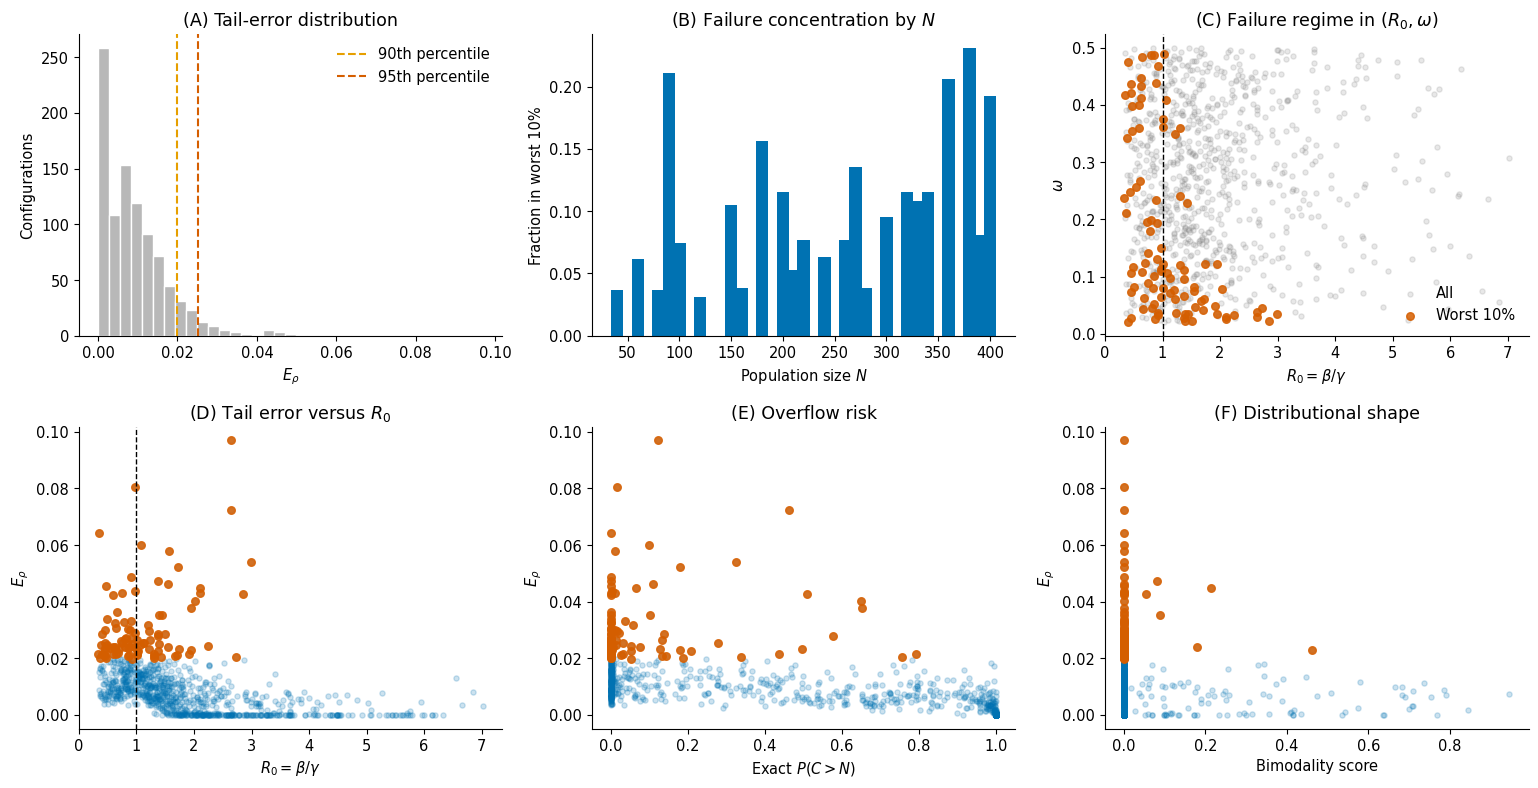


SIX WORST TEST CONFIGURATIONS
1. Exact-grid   | N=260, i0= 43 | beta=1.426, gamma=0.541, omega=0.029 | R0=2.637 | E2=0.0734, E_rho=0.0969
2. Interpolated | N=360, i0= 56 | beta=0.429, gamma=0.438, omega=0.110 | R0=0.979 | E2=0.0152, E_rho=0.0806
3. Exact-grid   | N=360, i0= 49 | beta=1.389, gamma=0.526, omega=0.038 | R0=2.641 | E2=0.0279, E_rho=0.0725
4. Interpolated | N=360, i0= 70 | beta=0.344, gamma=0.971, omega=0.418 | R0=0.354 | E2=0.0279, E_rho=0.0641
5. Interpolated | N=150, i0= 26 | beta=0.371, gamma=0.346, omega=0.107 | R0=1.072 | E2=0.0278, E_rho=0.0599
6. Interpolated | N=360, i0= 68 | beta=1.403, gamma=0.893, omega=0.047 | R0=1.570 | E2=0.0164, E_rho=0.0579


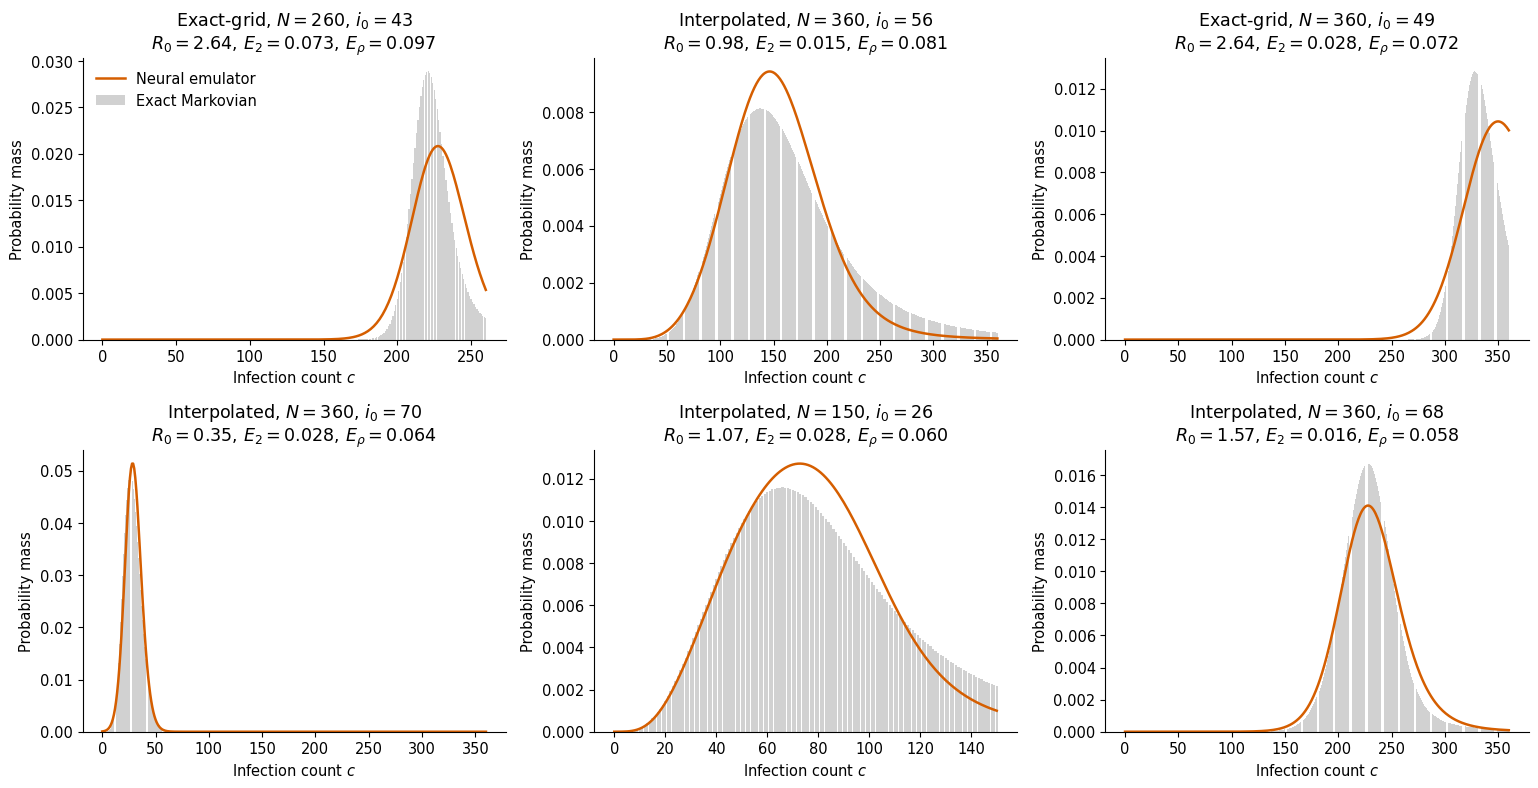

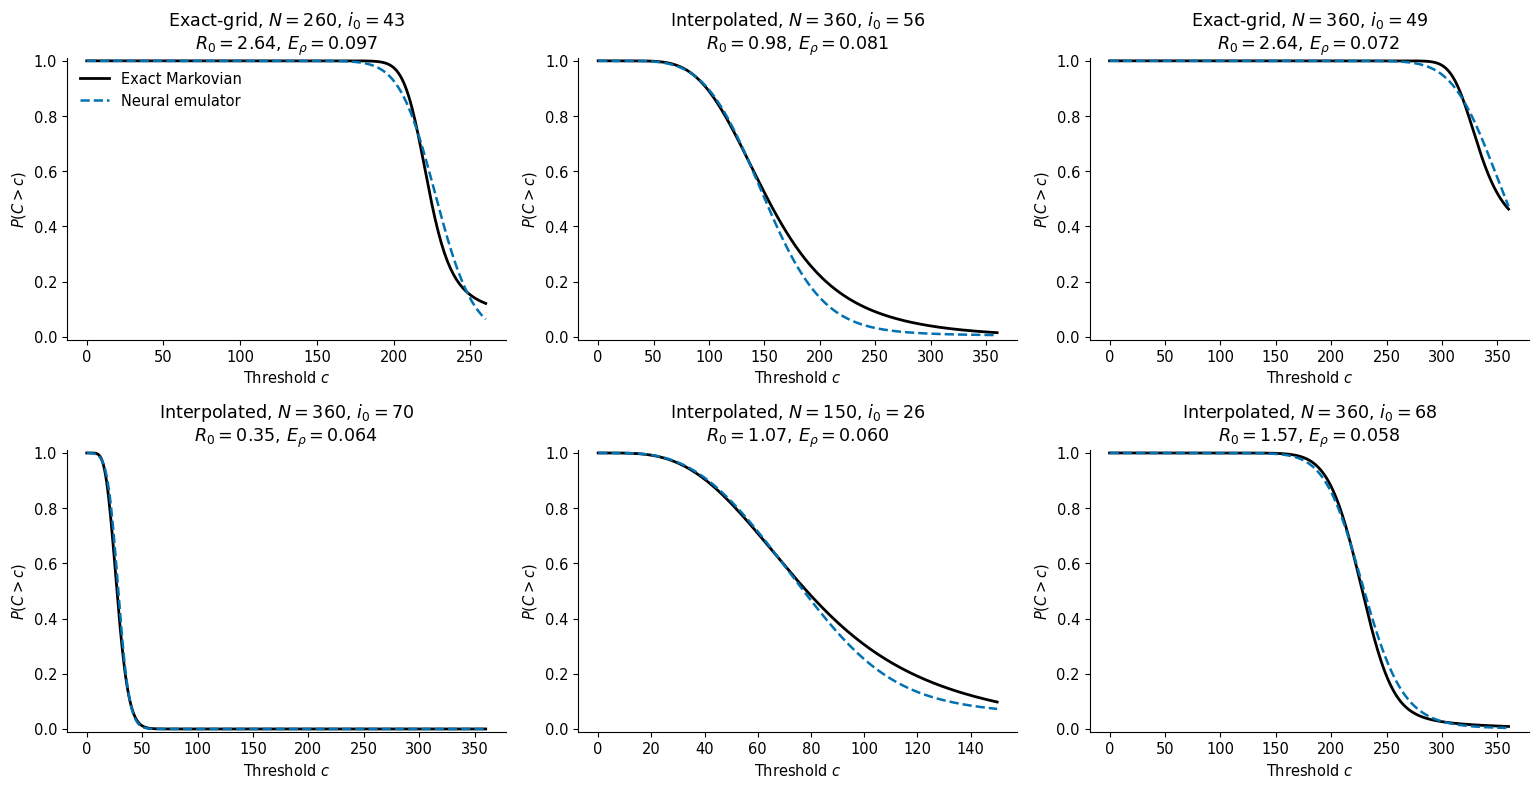


AUXILIARY-GRID BREAKDOWN


,N_group,n,median_Erho,p95_Erho,worst10_median_Erho,worst10_median_R0,worst10_i0_1_fraction
0,genuinely-intermediate,225,0.007094,0.025204,0.025274,1.133197,0.086957
1,represented-in-training,225,0.006890,0.024991,0.025203,0.917245,0.000000



FAILURE ANALYSIS COMPLETE
Primary metric: E_rho
Output directory:
/content/drive/MyDrive/StatisticalLearning/Experiment_5_2A_R10000/run_20260824_161227/results/failure_analysis

Important outputs:
/content/drive/MyDrive/StatisticalLearning/Experiment_5_2A_R10000/run_20260824_161227/results/failure_analysis/failure_regime_summary.csv
/content/drive/MyDrive/StatisticalLearning/Experiment_5_2A_R10000/run_20260824_161227/results/failure_analysis/auxiliary_failure_breakdown.csv
/content/drive/MyDrive/StatisticalLearning/Experiment_5_2A_R10000/run_20260824_161227/results/failure_analysis/figure_failure_diagnostics.pdf
/content/drive/MyDrive/StatisticalLearning/Experiment_5_2A_R10000/run_20260824_161227/results/failure_analysis/figure_worst6_pmfs.pdf
/content/drive/MyDrive/StatisticalLearning/Experiment_5_2A_R10000/run_20260824_161227/results/failure_analysis/figure_worst6_tails.pdf


In [4]:
# =====================================================================================
# SECTION 5.2 — FAILURE ANALYSIS
# Compatible with the immediately preceding manuscript-aligned 5.1-A cell.
#
# Primary failure metric: E_rho
# Worst fractions: 5%, 10%
#
# Uses CURRENT:
#   seen, interp, res_seen, res_interp, hnet, tnet, cfg, OUT
#
# No obsolete result pickle / no separate experiment directory.
# =====================================================================================

from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


FAIL_METRIC="E_rho"
FRACTIONS=(.05,.10)

FAIL_OUT=OUT/"failure_analysis"
FAIL_OUT.mkdir(parents=True,exist_ok=True)


# =====================================================================================
# 1. HELPERS
# =====================================================================================

def tail_np(p):
    return np.flip(
        np.cumsum(
            np.flip(
                p[1:]
            )
        )
    )


def entropy(p):
    z=np.asarray(p,float)
    z=z[z>0]
    return float(
        -np.sum(z*np.log(z))
    )


def bimodality(p):
    # Exclude overflow category.
    z=np.asarray(p[:-1],float)

    if len(z)<3 or z.max()<=0:
        return 0.

    peaks=[
        j
        for j in range(len(z))
        if
        z[j] >= (z[j-1] if j else -np.inf)
        and
        z[j] >= (z[j+1] if j<len(z)-1 else -np.inf)
        and
        z[j] >= .03*z.max()
    ]

    if len(peaks)<2:
        return 0.

    a,b=sorted(
        peaks,
        key=lambda j:z[j],
        reverse=True
    )[:2]

    return float(
        min(z[a],z[b])
        /
        max(z[a],z[b])
        *
        abs(a-b)
        /
        max(len(z)-1,1)
    )


# =====================================================================================
# 2. RECONSTRUCT CASE-LEVEL RESULTS
#
# res_seen / res_interp come directly from the preceding Section 5.2 cell.
# We recompute only predictions needed for PMF/tail diagnostic plots.
# =====================================================================================

@torch.no_grad()
def detailed_results(
    records,
    packed,
    results,
    split
):
    hnet.eval()
    tnet.eval()

    rows=[]

    for N,G in packed.items():

        for s in range(
            0,
            G["n"],
            cfg.batch
        ):

            e=min(
                s+cfg.batch,
                G["n"]
            )

            loc=np.arange(s,e)
            orig=G["orig"][loc]

            Ph=pred_p(
                hnet,
                G["Xh"][loc]
            ).numpy()

            for q,j in enumerate(orig):

                r=records[int(j)]

                exact_p=np.asarray(
                    r.p,
                    dtype=float
                )

                pred_p_case=np.asarray(
                    Ph[q],
                    dtype=float
                )

                exact_tail=tail_np(
                    exact_p
                )

                pred_tail=tail_np(
                    pred_p_case
                )

                rows.append({

                    "index":
                        int(j),

                    "split":
                        split,

                    "N":
                        r.N,

                    "i0":
                        r.i0,

                    "i0_fraction":
                        r.i0/r.N,

                    "beta":
                        r.b,

                    "gamma":
                        r.g,

                    "omega":
                        r.w,

                    "R0":
                        r.b/r.g,

                    "E2":
                        float(
                            results["E2"][j]
                        ),

                    "E_rho":
                        float(
                            results["Erho"][j]
                        ),

                    "E_overflow":
                        float(
                            results["Eover"][j]
                        ),

                    "KL":
                        float(
                            results["KL"][j]
                        ),

                    "mean_tau_relative_error":
                        float(
                            results["mean_tau_rel"][j]
                        ),

                    "var_tau_relative_error":
                        float(
                            results["var_tau_rel"][j]
                        ),

                    "exact_overflow":
                        float(
                            exact_p[-1]
                        ),

                    "entropy":
                        entropy(
                            exact_p
                        ),

                    "bimodality":
                        bimodality(
                            exact_p
                        ),

                    "tau_valid":
                        bool(
                            r.tv
                        ),

                    "N_seen_in_training":
                        r.N in cfg.train_N,

                    "exact_p":
                        exact_p,

                    "pred_p":
                        pred_p_case,

                    "exact_tail":
                        exact_tail,

                    "pred_tail":
                        pred_tail

                })

    # Restore original test-set ordering.
    rows.sort(
        key=lambda x:x["index"]
    )

    return rows


ALL_SEEN=detailed_results(
    seen,
    SE,
    res_seen,
    "Exact-grid"
)

ALL_INTERP=detailed_results(
    interp,
    IN,
    res_interp,
    "Interpolated"
)

ALL=ALL_SEEN+ALL_INTERP


# =====================================================================================
# 3. DATA FRAMES
# =====================================================================================

SCALAR_COLUMNS=[
    "index",
    "split",
    "N",
    "i0",
    "i0_fraction",
    "beta",
    "gamma",
    "omega",
    "R0",
    "E2",
    "E_rho",
    "E_overflow",
    "KL",
    "mean_tau_relative_error",
    "var_tau_relative_error",
    "exact_overflow",
    "entropy",
    "bimodality",
    "tau_valid",
    "N_seen_in_training"
]


def to_df(results):
    return pd.DataFrame([
        {
            k:r[k]
            for k in SCALAR_COLUMNS
        }
        for r in results
    ])


df_all=to_df(ALL)
df_interp=to_df(ALL_INTERP)


df_all.to_csv(
    FAIL_OUT/"all_test_failure_data.csv",
    index=False
)


# =====================================================================================
# 4. WORST 5% / 10%
# =====================================================================================

def worst_fraction(
    df,
    fraction
):
    n=max(
        1,
        int(
            math.ceil(
                fraction*len(df)
            )
        )
    )

    return (
        df
        .nlargest(
            n,
            FAIL_METRIC
        )
        .copy()
    )


W={}


for scope,df in (
    ("all",df_all),
    ("interpolation",df_interp)
):

    print("\n"+"="*105)
    print(scope.upper())
    print("="*105)

    for frac in FRACTIONS:

        w=worst_fraction(
            df,
            frac
        )

        W[
            (scope,frac)
        ]=w

        print(
            f"\nWorst {100*frac:.0f}% | "
            f"n={len(w)}/{len(df)}"
        )

        print(
            f"E_rho median={w.E_rho.median():.4f}, "
            f"range=({w.E_rho.min():.4f}, "
            f"{w.E_rho.max():.4f})"
        )

        print(
            f"R0 median={w.R0.median():.3f}, "
            f"IQR=({w.R0.quantile(.25):.3f}, "
            f"{w.R0.quantile(.75):.3f})"
        )

        print(
            f"i0=1 fraction={(w.i0==1).mean():.3f}"
        )

        print(
            "N counts:",
            w.N.value_counts()
            .sort_index()
            .to_dict()
        )

        w.to_csv(
            FAIL_OUT
            /
            f"worst_{int(100*frac)}pct_{scope}.csv",
            index=False
        )


# =====================================================================================
# 5. ALL TEST vs WORST 10%
# =====================================================================================

w10=W[
    ("all",.10)
]


compare_cols=[
    "N",
    "i0_fraction",
    "beta",
    "gamma",
    "omega",
    "R0",
    "exact_overflow",
    "entropy",
    "bimodality",
    "E2",
    "E_rho",
    "KL"
]


comparison=pd.DataFrame({

    "all_test_median":
        df_all[
            compare_cols
        ].median(),

    "worst10_median":
        w10[
            compare_cols
        ].median(),

    "worst10_Q25":
        w10[
            compare_cols
        ].quantile(.25),

    "worst10_Q75":
        w10[
            compare_cols
        ].quantile(.75)

})


print("\n"+"="*105)
print("ALL TEST vs WORST 10%")
print("="*105)

display(
    comparison
)


comparison.to_csv(
    FAIL_OUT
    /
    "failure_regime_summary.csv"
)


# =====================================================================================
# 6. FAILURE DIAGNOSTICS
# =====================================================================================

fig,axs=plt.subplots(
    2,3,
    figsize=(15.5,8)
)


# A — tail-error distribution
axs[0,0].hist(
    df_all.E_rho,
    bins=35,
    color=".72",
    edgecolor="white"
)

for q,color,label in (
    (.90,"#E69F00","90th percentile"),
    (.95,"#D55E00","95th percentile")
):
    axs[0,0].axvline(
        df_all.E_rho.quantile(q),
        color=color,
        ls="--",
        label=label
    )

axs[0,0].set(
    xlabel=r"$E_\rho$",
    ylabel="Configurations",
    title="(A) Tail-error distribution"
)

axs[0,0].legend(
    frameon=False
)


# B — concentration by N
allN=df_all.groupby("N").size()
badN=w10.groupby("N").size()

rate=(
    badN.reindex(
        allN.index,
        fill_value=0
    )
    /
    allN
)

axs[0,1].bar(
    rate.index,
    rate.values,
    width=12,
    color="#0072B2"
)

axs[0,1].set(
    xlabel="Population size $N$",
    ylabel="Fraction in worst 10%",
    title="(B) Failure concentration by $N$"
)


# C — R0 and omega
axs[0,2].scatter(
    df_all.R0,
    df_all.omega,
    s=14,
    alpha=.18,
    color=".5",
    label="All"
)

axs[0,2].scatter(
    w10.R0,
    w10.omega,
    s=30,
    alpha=.85,
    color="#D55E00",
    label="Worst 10%"
)

axs[0,2].axvline(
    1,
    color="black",
    ls="--",
    lw=1
)

axs[0,2].set(
    xlabel=r"$R_0=\beta/\gamma$",
    ylabel=r"$\omega$",
    title=r"(C) Failure regime in $(R_0,\omega)$"
)

axs[0,2].legend(
    frameon=False
)


# D — R0 versus tail error
axs[1,0].scatter(
    df_all.R0,
    df_all.E_rho,
    s=14,
    alpha=.20,
    color="#0072B2"
)

axs[1,0].scatter(
    w10.R0,
    w10.E_rho,
    s=30,
    alpha=.85,
    color="#D55E00"
)

axs[1,0].axvline(
    1,
    color="black",
    ls="--",
    lw=1
)

axs[1,0].set(
    xlabel=r"$R_0=\beta/\gamma$",
    ylabel=r"$E_\rho$",
    title=r"(D) Tail error versus $R_0$"
)


# E — overflow
axs[1,1].scatter(
    df_all.exact_overflow,
    df_all.E_rho,
    s=14,
    alpha=.20,
    color="#0072B2"
)

axs[1,1].scatter(
    w10.exact_overflow,
    w10.E_rho,
    s=30,
    alpha=.85,
    color="#D55E00"
)

axs[1,1].set(
    xlabel=r"Exact $P(C>N)$",
    ylabel=r"$E_\rho$",
    title="(E) Overflow risk"
)


# F — distributional shape
axs[1,2].scatter(
    df_all.bimodality,
    df_all.E_rho,
    s=14,
    alpha=.20,
    color="#0072B2"
)

axs[1,2].scatter(
    w10.bimodality,
    w10.E_rho,
    s=30,
    alpha=.85,
    color="#D55E00"
)

axs[1,2].set(
    xlabel="Bimodality score",
    ylabel=r"$E_\rho$",
    title="(F) Distributional shape"
)


plt.tight_layout()

plt.savefig(
    FAIL_OUT/"figure_failure_diagnostics.pdf",
    bbox_inches="tight"
)

plt.savefig(
    FAIL_OUT/"figure_failure_diagnostics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =====================================================================================
# 7. SIX WORST CONFIGURATIONS
# =====================================================================================

worst6=sorted(
    ALL,
    key=lambda r:r[FAIL_METRIC],
    reverse=True
)[:6]


print("\n"+"="*105)
print("SIX WORST TEST CONFIGURATIONS")
print("="*105)


for j,r in enumerate(
    worst6,
    1
):
    print(
        f"{j}. {r['split']:12s} | "
        f"N={r['N']:3d}, i0={r['i0']:3d} | "
        f"beta={r['beta']:.3f}, "
        f"gamma={r['gamma']:.3f}, "
        f"omega={r['omega']:.3f} | "
        f"R0={r['R0']:.3f} | "
        f"E2={r['E2']:.4f}, "
        f"E_rho={r['E_rho']:.4f}"
    )


# =====================================================================================
# 8. WORST-6 PMFs
# =====================================================================================

fig,axs=plt.subplots(
    2,3,
    figsize=(15.5,8)
)


for ax,r in zip(
    axs.flat,
    worst6
):

    c=np.arange(
        r["N"]+1
    )

    ax.bar(
        c,
        r["exact_p"][:-1],
        color=".82",
        width=.85,
        label="Exact Markovian"
    )

    ax.plot(
        c,
        r["pred_p"][:-1],
        color="#D55E00",
        lw=1.8,
        label="Neural emulator"
    )

    ax.set_title(
        f"{r['split']}, "
        f"$N={r['N']}$, "
        f"$i_0={r['i0']}$\n"
        rf"$R_0={r['R0']:.2f}$, "
        rf"$E_2={r['E2']:.3f}$, "
        rf"$E_\rho={r['E_rho']:.3f}$"
    )

    ax.set_xlabel(
        "Infection count $c$"
    )

    ax.set_ylabel(
        "Probability mass"
    )


axs[0,0].legend(
    frameon=False
)

plt.tight_layout()

plt.savefig(
    FAIL_OUT/"figure_worst6_pmfs.pdf",
    bbox_inches="tight"
)

plt.savefig(
    FAIL_OUT/"figure_worst6_pmfs.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =====================================================================================
# 9. WORST-6 TAIL-RISK FUNCTIONS
# =====================================================================================

fig,axs=plt.subplots(
    2,3,
    figsize=(15.5,8)
)


for ax,r in zip(
    axs.flat,
    worst6
):

    c=np.arange(
        r["N"]+1
    )

    ax.plot(
        c,
        r["exact_tail"],
        color="black",
        lw=2,
        label="Exact Markovian"
    )

    ax.plot(
        c,
        r["pred_tail"],
        "--",
        color="#0072B2",
        lw=1.8,
        label="Neural emulator"
    )

    ax.set_ylim(
        -.01,
        1.01
    )

    ax.set_title(
        f"{r['split']}, "
        f"$N={r['N']}$, "
        f"$i_0={r['i0']}$\n"
        rf"$R_0={r['R0']:.2f}$, "
        rf"$E_\rho={r['E_rho']:.3f}$"
    )

    ax.set_xlabel(
        "Threshold $c$"
    )

    ax.set_ylabel(
        r"$P(C>c)$"
    )


axs[0,0].legend(
    frameon=False
)

plt.tight_layout()

plt.savefig(
    FAIL_OUT/"figure_worst6_tails.pdf",
    bbox_inches="tight"
)

plt.savefig(
    FAIL_OUT/"figure_worst6_tails.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =====================================================================================
# 10. AUXILIARY-GRID FAILURE BREAKDOWN
#
# Important because Section 5.2 N_int contains both training-grid and
# genuinely intermediate population sizes.
# =====================================================================================

aux=df_interp.copy()

aux["N_group"]=np.where(
    aux.N.isin(
        cfg.train_N
    ),
    "represented-in-training",
    "genuinely-intermediate"
)


aux_failure=[]

for group,z in aux.groupby(
    "N_group"
):

    w=worst_fraction(
        z,
        .10
    )

    aux_failure.append({

        "N_group":
            group,

        "n":
            len(z),

        "median_Erho":
            z.E_rho.median(),

        "p95_Erho":
            z.E_rho.quantile(.95),

        "worst10_median_Erho":
            w.E_rho.median(),

        "worst10_median_R0":
            w.R0.median(),

        "worst10_i0_1_fraction":
            (w.i0==1).mean()

    })


aux_failure=pd.DataFrame(
    aux_failure
)


aux_failure.to_csv(
    FAIL_OUT/"auxiliary_failure_breakdown.csv",
    index=False
)


print("\nAUXILIARY-GRID BREAKDOWN")
display(
    aux_failure
)


# =====================================================================================
# 11. SAVE DETAILED RESULT OBJECT
# =====================================================================================

apickle(
    {
        "all_test":
            ALL,

        "seen":
            ALL_SEEN,

        "interpolation":
            ALL_INTERP,

        "failure_metric":
            FAIL_METRIC,

        "fractions":
            FRACTIONS
    },
    FAIL_OUT/"failure_analysis_results.pkl"
)


print("\n"+"="*105)
print("FAILURE ANALYSIS COMPLETE")
print("="*105)

print("Primary metric:",FAIL_METRIC)
print("Output directory:")
print(FAIL_OUT)

print("\nImportant outputs:")
print(FAIL_OUT/"failure_regime_summary.csv")
print(FAIL_OUT/"auxiliary_failure_breakdown.csv")
print(FAIL_OUT/"figure_failure_diagnostics.pdf")
print(FAIL_OUT/"figure_worst6_pmfs.pdf")
print(FAIL_OUT/"figure_worst6_tails.pdf")

print("="*105)

Excluding 6 previously selected cases.

SHAPE COUNTS BASED ON EXACT PMF
unimodal      420
decreasing    389
other          89
bimodal        52
Name: count, dtype: int64

SELECTED SIX ADDITIONAL REPRESENTATIVE CASES WITH HIGH VISUAL COHERENCE
1. decreasing | pred=decreasing | Interpolated | N= 60, i0=  1 | R0=3.477 | score=0.005701, TV=0.0019, CDF=0.0002, corr=1.000, mode=0->0, q95=3->3, KL=0.0005912
2. decreasing | pred=decreasing | Exact-grid   | N= 60, i0=  1 | R0=4.071 | score=0.0097484, TV=0.0035, CDF=0.0002, corr=1.000, mode=0->0, q95=2->2, KL=0.0002774
3. unimodal   | pred=unimodal   | Exact-grid   | N=100, i0= 16 | R0=0.610 | score=0.016108, TV=0.0056, CDF=0.0007, corr=1.000, mode=11->11, q95=31->31, KL=0.0002373
4. unimodal   | pred=unimodal   | Interpolated | N= 90, i0= 17 | R0=0.732 | score=0.018311, TV=0.0068, CDF=0.0014, corr=1.000, mode=15->15, q95=40->40, KL=0.0004998
5. bimodal    | pred=bimodal    | Exact-grid   | N= 60, i0=  5 | R0=1.840 | score=0.079618, TV=0.0292, C

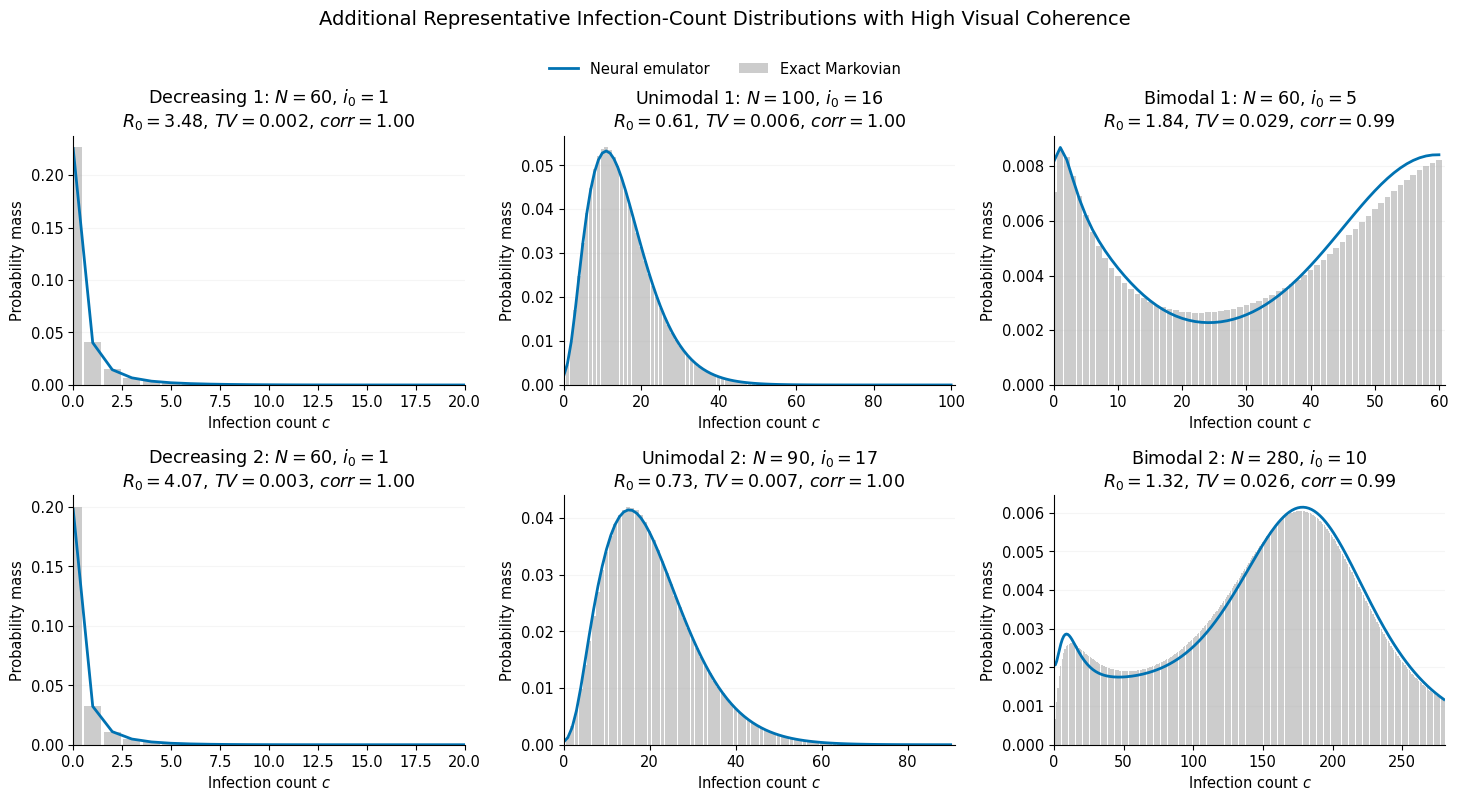

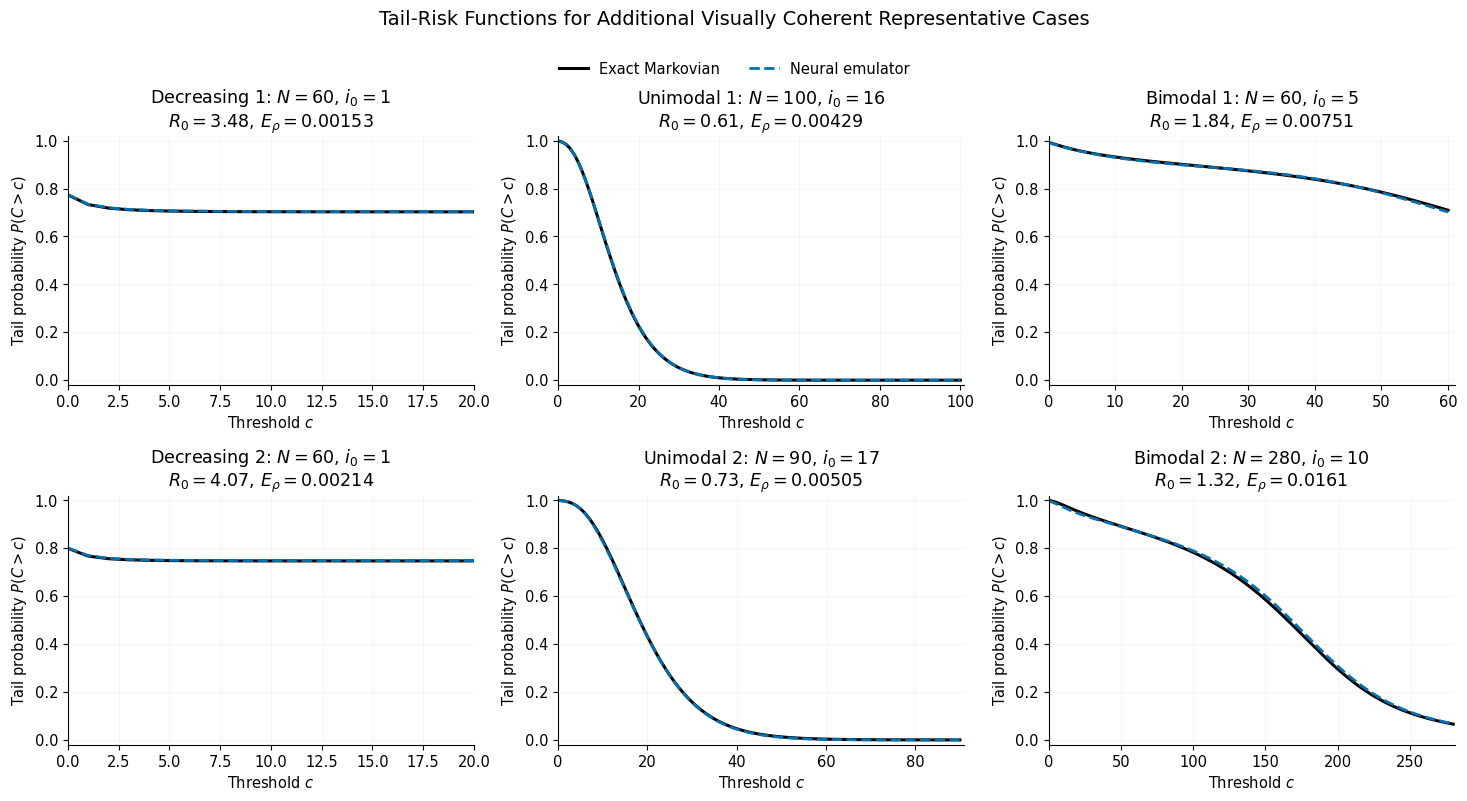


COHERENCE-BASED CASE FIGURES COMPLETE
Selected cases: /content/drive/MyDrive/StatisticalLearning/Experiment_5_2A_R10000/run_20260824_161227/results/additional_coherent_representative_cases/selected_additional_coherent_six.csv
PMF figure: /content/drive/MyDrive/StatisticalLearning/Experiment_5_2A_R10000/run_20260824_161227/results/additional_coherent_representative_cases/figure_additional_coherent6_pmfs.pdf
Tail-risk figure: /content/drive/MyDrive/StatisticalLearning/Experiment_5_2A_R10000/run_20260824_161227/results/additional_coherent_representative_cases/figure_additional_coherent6_tail_risks.pdf


,shape,pred_shape,same_shape,passes_coherence,rank,split,N,i0,beta,gamma,...,q99_pred,q95_dist,q99_dist,log_peak_ratio,body_mass_exact,body_mass_pred,body_mass_diff,E2,E_rho,exact_overflow
0,decreasing,decreasing,1,True,1,Interpolated,60,1,1.480386,0.425807,...,6,0.000000,0.000000,0.004354,0.297401,0.296135,1.266196e-03,0.001668,0.001531,7.025991e-01
1,decreasing,decreasing,1,True,2,Exact-grid,60,1,1.256424,0.308600,...,5,0.000000,0.000000,0.008507,0.252799,0.251345,1.454291e-03,0.002301,0.002138,7.472006e-01
2,unimodal,unimodal,1,True,1,Exact-grid,100,16,0.515112,0.844469,...,40,0.000000,0.000000,0.014949,1.000000,1.000000,1.873888e-07,0.002247,0.004289,3.179260e-07
3,unimodal,unimodal,1,True,2,Interpolated,90,17,0.712149,0.973379,...,51,0.000000,0.011111,0.011523,0.999924,0.999989,6.517532e-05,0.002603,0.005053,7.616560e-05
4,bimodal,bimodal,1,True,1,Exact-grid,60,5,1.115371,0.606028,...,60,0.000000,0.000000,0.016792,0.290682,0.298191,7.508621e-03,0.008091,0.007509,7.093175e-01
5,bimodal,bimodal,1,True,2,Exact-grid,280,10,1.028362,0.778769,...,273,0.003571,0.000000,0.015413,0.934035,0.932389,1.646386e-03,0.004264,0.016075,6.596458e-02


In [5]:
# =====================================================================================
# SECTION 5.2 — SIX ADDITIONAL VISUALLY COHERENT REPRESENTATIVE CASES
#
# Select:
#   2 decreasing
#   2 unimodal
#   2 bimodal
#
# Goal:
#   Choose cases where the emulator PMF is visually coherent with the exact PMF.
#
# Special rule:
#   Decreasing cases are selected from visually readable left-concentrated examples,
#   avoiding cases whose mass is far outside the displayed x-axis range.
#
# Requires:
#   ALL, OUT
# =====================================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from pathlib import Path


# =====================================================================================
# 0. REQUIRED OBJECTS CHECK
# =====================================================================================

if "ALL" not in globals():
    raise NameError(
        "ALL is not defined. Rerun the previous Section 5.2 / failure-analysis cell "
        "that constructs ALL, then rerun this cell."
    )

if "OUT" not in globals():
    raise NameError(
        "OUT is not defined. Rerun the setup cell where OUT is defined."
    )


# =====================================================================================
# 1. OUTPUT
# =====================================================================================

COH_OUT = OUT / "additional_coherent_representative_cases"
COH_OUT.mkdir(parents=True, exist_ok=True)

N_PER_SHAPE = 2
EXCLUDE_PREVIOUS = True


# =====================================================================================
# 2. EXACT-PMF SHAPE CLASSIFICATION
# =====================================================================================

def classify_pmf(
    p,
    prominence_fraction=.05,
    min_peak_separation_fraction=.08,
    monotone_tolerance=.015
):
    """
    Classify PMF as:
        decreasing
        unimodal
        bimodal
        other

    The overflow category P(C>N) is excluded from shape classification.
    """

    y = np.asarray(p[:-1], dtype=float)

    if len(y) < 3 or not np.all(np.isfinite(y)) or np.max(y) <= 0:
        return "other"

    z = y / np.max(y)

    # Decreasing: allow tiny local deviations.
    if np.all(np.diff(z) <= monotone_tolerance):
        return "decreasing"

    distance = max(
        2,
        int(round(min_peak_separation_fraction * len(z)))
    )

    peaks, _ = find_peaks(
        z,
        prominence=prominence_fraction,
        distance=distance
    )

    peaks = list(peaks)

    # Include endpoints if they are genuine local modes.
    if z[0] > z[1] and z[0] >= prominence_fraction:
        peaks.append(0)

    if z[-1] > z[-2] and z[-1] >= prominence_fraction:
        peaks.append(len(z) - 1)

    peaks = sorted(set(peaks))

    peaks = [
        j
        for j in peaks
        if z[j] >= prominence_fraction
    ]

    if len(peaks) == 0:
        return "other"

    if len(peaks) == 1:
        return "unimodal"

    dominant = sorted(
        peaks,
        key=lambda j: z[j],
        reverse=True
    )[:2]

    a, b = sorted(dominant)

    separation = (b - a) / max(len(z) - 1, 1)
    smaller_peak = min(z[a], z[b])
    valley = np.min(z[a:b+1])
    valley_ratio = valley / max(smaller_peak, 1e-12)

    if (
        separation >= min_peak_separation_fraction
        and smaller_peak >= .10
        and valley_ratio <= .80
    ):
        return "bimodal"

    return "unimodal"


# =====================================================================================
# 3. COHERENCE METRICS
# =====================================================================================

def normalize_body(p, eps=1e-15):
    """
    Exclude overflow category and normalize the body PMF over c=0,...,N.
    """

    y = np.asarray(p[:-1], dtype=float)
    y = np.where(np.isfinite(y), y, 0.0)
    y = np.clip(y, 0.0, None)

    mass = float(y.sum())

    if mass <= eps:
        z = np.ones_like(y) / len(y)
    else:
        z = y / mass

    return y, z, mass


def pmf_quantile(p, q):
    """
    Quantile index for a normalized PMF over c=0,...,N.
    """

    p = np.asarray(p, dtype=float)
    cdf = np.cumsum(p)

    return int(np.searchsorted(cdf, q, side="left"))


def kl_divergence(p, q, eps=1e-15):
    p = np.clip(np.asarray(p, dtype=float), eps, None)
    q = np.clip(np.asarray(q, dtype=float), eps, None)

    p = p / p.sum()
    q = q / q.sum()

    return float(np.sum(p * np.log(p / q)))


def js_divergence(p, q, eps=1e-15):
    p = np.clip(np.asarray(p, dtype=float), eps, None)
    q = np.clip(np.asarray(q, dtype=float), eps, None)

    p = p / p.sum()
    q = q / q.sum()

    m = 0.5 * (p + q)

    return 0.5 * kl_divergence(p, m, eps) + 0.5 * kl_divergence(q, m, eps)


def compute_coherence_metrics(exact_p, pred_p, eps=1e-15):
    """
    Metrics designed to favor visually coherent PMF overlays.
    """

    raw_p, p, mass_p = normalize_body(exact_p, eps)
    raw_q, q, mass_q = normalize_body(pred_p, eps)

    n = len(p)
    denom = max(n - 1, 1)

    kl = kl_divergence(p, q, eps)
    js = js_divergence(p, q, eps)

    tv = 0.5 * float(np.sum(np.abs(p - q)))

    cdf_dist = float(
        np.sum(np.abs(np.cumsum(p) - np.cumsum(q))) / denom
    )

    if np.std(p) > eps and np.std(q) > eps:
        corr = float(np.corrcoef(p, q)[0, 1])
    else:
        corr = 0.0

    corr_loss = 1.0 - max(corr, 0.0)

    mode_p = int(np.argmax(p))
    mode_q = int(np.argmax(q))

    mode_dist = abs(mode_p - mode_q) / denom

    q90_p = pmf_quantile(p, .90)
    q95_p = pmf_quantile(p, .95)
    q99_p = pmf_quantile(p, .99)

    q90_q = pmf_quantile(q, .90)
    q95_q = pmf_quantile(q, .95)
    q99_q = pmf_quantile(q, .99)

    q95_dist = abs(q95_p - q95_q) / denom
    q99_dist = abs(q99_p - q99_q) / denom

    peak_p = float(np.max(raw_p))
    peak_q = float(np.max(raw_q))

    log_peak_ratio = abs(
        np.log(max(peak_q, eps) / max(peak_p, eps))
    )

    body_mass_diff = abs(mass_p - mass_q)

    exact_shape = classify_pmf(exact_p)
    pred_shape = classify_pmf(pred_p)

    same_shape = int(exact_shape == pred_shape)

    passes_coherence = (
        same_shape == 1
        and tv <= 0.25
        and cdf_dist <= 0.06
        and mode_dist <= 0.10
        and q95_dist <= 0.10
        and corr >= 0.85
        and log_peak_ratio <= np.log(2.5)
    )

    coherence_score = (
        2.00 * js
        + 1.70 * tv
        + 1.70 * cdf_dist
        + 1.00 * mode_dist
        + 0.80 * q95_dist
        + 0.75 * corr_loss
        + 0.35 * log_peak_ratio
        + 0.25 * body_mass_diff
        + (0.50 if same_shape == 0 else 0.0)
    )

    return {
        "KL_body": kl,
        "JS_body": js,
        "TV_body": tv,
        "CDF_dist": cdf_dist,
        "corr": corr,
        "mode_exact": mode_p,
        "mode_pred": mode_q,
        "mode_dist": mode_dist,
        "q90_exact": q90_p,
        "q95_exact": q95_p,
        "q99_exact": q99_p,
        "q90_pred": q90_q,
        "q95_pred": q95_q,
        "q99_pred": q99_q,
        "q95_dist": q95_dist,
        "q99_dist": q99_dist,
        "log_peak_ratio": log_peak_ratio,
        "body_mass_exact": mass_p,
        "body_mass_pred": mass_q,
        "body_mass_diff": body_mass_diff,
        "exact_shape": exact_shape,
        "pred_shape": pred_shape,
        "same_shape": same_shape,
        "passes_coherence": passes_coherence,
        "coherence_score": coherence_score
    }


# =====================================================================================
# 4. CASE IDENTIFIER FOR EXCLUSION
# =====================================================================================

def case_key(r):
    return (
        int(r["N"]),
        int(r["i0"]),
        round(float(r["beta"]), 10),
        round(float(r["gamma"]), 10),
        round(float(r["omega"]), 10),
        str(r["split"])
    )


exclude_keys = set()

old_csv = OUT / "best_representative_cases" / "selected_best_six.csv"

if EXCLUDE_PREVIOUS and old_csv.exists():

    old = pd.read_csv(old_csv)

    for _, row in old.iterrows():
        exclude_keys.add((
            int(row["N"]),
            int(row["i0"]),
            round(float(row["beta"]), 10),
            round(float(row["gamma"]), 10),
            round(float(row["omega"]), 10),
            str(row["split"])
        ))

    print(f"Excluding {len(exclude_keys)} previously selected cases.")


# =====================================================================================
# 5. CLASSIFY ALL CASES AND COMPUTE COHERENCE SCORE
# =====================================================================================

classified = []

for r in ALL:

    rr = dict(r)

    metrics = compute_coherence_metrics(
        rr["exact_p"],
        rr["pred_p"]
    )

    rr.update(metrics)

    # Selection class is based on the exact PMF.
    rr["shape"] = rr["exact_shape"]

    rr["case_key"] = case_key(rr)

    classified.append(rr)


shape_counts = pd.Series(
    [r["shape"] for r in classified]
).value_counts()

print("\n" + "=" * 100)
print("SHAPE COUNTS BASED ON EXACT PMF")
print("=" * 100)
print(shape_counts)


# =====================================================================================
# 6. SELECT CASES
# =====================================================================================

shape_order = (
    "decreasing",
    "unimodal",
    "bimodal"
)

selected = []


def base_candidate_filter(r, shape):
    return (
        r["shape"] == shape
        and np.isfinite(r["coherence_score"])
        and r["case_key"] not in exclude_keys
    )


def sort_key(r):
    return (
        not r["passes_coherence"],
        r["coherence_score"],
        r["TV_body"],
        r["CDF_dist"],
        r["mode_dist"],
        r["q95_dist"],
        -r["corr"],
        r["KL_body"],
        r.get("E_rho", np.inf),
        r.get("E2", np.inf)
    )


# -------------------------------------------------------------------------------------
# 6A. Decreasing cases: force readable left-concentrated profiles.
# -------------------------------------------------------------------------------------

decreasing_candidates = [
    r for r in classified
    if base_candidate_filter(r, "decreasing")
]

# Main readable pool for decreasing cases.
decreasing_readable = [
    r for r in decreasing_candidates
    if (
        r["mode_exact"] <= max(3, int(0.03 * r["N"]))
        and r["q95_exact"] <= max(8, int(0.35 * r["N"]))
        and r["q99_exact"] <= max(12, int(0.50 * r["N"]))
        and r["q95_pred"] <= max(8, int(0.40 * r["N"]))
        and r["corr"] >= 0.90
        and r["TV_body"] <= 0.10
    )
]

# Fallback readable pool if the strict pool is too small.
if len(decreasing_readable) < N_PER_SHAPE:
    decreasing_readable = [
        r for r in decreasing_candidates
        if (
            r["mode_exact"] <= max(5, int(0.08 * r["N"]))
            and r["q95_exact"] <= max(15, int(0.60 * r["N"]))
            and r["corr"] >= 0.80
            and r["TV_body"] <= 0.20
        )
    ]

# Final fallback: any decreasing cases by coherence.
if len(decreasing_readable) < N_PER_SHAPE:
    decreasing_readable = decreasing_candidates

decreasing_readable = sorted(decreasing_readable, key=sort_key)

for rank, r in enumerate(decreasing_readable[:N_PER_SHAPE], 1):
    rr = dict(r)
    rr["shape_rank"] = rank
    selected.append(rr)


# -------------------------------------------------------------------------------------
# 6B. Unimodal and bimodal cases.
# -------------------------------------------------------------------------------------

for shape in ("unimodal", "bimodal"):

    candidates = [
        r for r in classified
        if base_candidate_filter(r, shape)
    ]

    # Prefer cases where the predicted shape agrees with the exact shape.
    coherent_candidates = [
        r for r in candidates
        if r["same_shape"] == 1
    ]

    if len(coherent_candidates) >= N_PER_SHAPE:
        candidates = coherent_candidates

    candidates = sorted(candidates, key=sort_key)

    if len(candidates) < N_PER_SHAPE:
        print(
            f"WARNING: only {len(candidates)} additional "
            f"{shape} cases detected."
        )

    for rank, r in enumerate(candidates[:N_PER_SHAPE], 1):
        rr = dict(r)
        rr["shape_rank"] = rank
        selected.append(rr)


selected = sorted(
    selected,
    key=lambda r: (
        shape_order.index(r["shape"]),
        r["shape_rank"]
    )
)


# =====================================================================================
# 7. PRINT + SAVE SELECTED CASES
# =====================================================================================

print("\n" + "=" * 120)
print("SELECTED SIX ADDITIONAL REPRESENTATIVE CASES WITH HIGH VISUAL COHERENCE")
print("=" * 120)

summary_rows = []

for j, r in enumerate(selected, 1):

    print(
        f"{j}. "
        f"{r['shape']:10s} | pred={r['pred_shape']:10s} | "
        f"{r['split']:12s} | "
        f"N={r['N']:3d}, "
        f"i0={r['i0']:3d} | "
        f"R0={r['R0']:.3f} | "
        f"score={r['coherence_score']:.5g}, "
        f"TV={r['TV_body']:.4f}, "
        f"CDF={r['CDF_dist']:.4f}, "
        f"corr={r['corr']:.3f}, "
        f"mode={r['mode_exact']}->{r['mode_pred']}, "
        f"q95={r['q95_exact']}->{r['q95_pred']}, "
        f"KL={r['KL_body']:.4g}"
    )

    summary_rows.append({
        "shape": r["shape"],
        "pred_shape": r["pred_shape"],
        "same_shape": r["same_shape"],
        "passes_coherence": r["passes_coherence"],
        "rank": r["shape_rank"],
        "split": r["split"],
        "N": r["N"],
        "i0": r["i0"],
        "beta": r["beta"],
        "gamma": r["gamma"],
        "omega": r["omega"],
        "R0": r["R0"],
        "coherence_score": r["coherence_score"],
        "KL_body": r["KL_body"],
        "JS_body": r["JS_body"],
        "TV_body": r["TV_body"],
        "CDF_dist": r["CDF_dist"],
        "corr": r["corr"],
        "mode_exact": r["mode_exact"],
        "mode_pred": r["mode_pred"],
        "mode_dist": r["mode_dist"],
        "q90_exact": r["q90_exact"],
        "q95_exact": r["q95_exact"],
        "q99_exact": r["q99_exact"],
        "q90_pred": r["q90_pred"],
        "q95_pred": r["q95_pred"],
        "q99_pred": r["q99_pred"],
        "q95_dist": r["q95_dist"],
        "q99_dist": r["q99_dist"],
        "log_peak_ratio": r["log_peak_ratio"],
        "body_mass_exact": r["body_mass_exact"],
        "body_mass_pred": r["body_mass_pred"],
        "body_mass_diff": r["body_mass_diff"],
        "E2": r.get("E2", np.nan),
        "E_rho": r.get("E_rho", np.nan),
        "exact_overflow": r.get("exact_overflow", np.nan)
    })


selected_table = pd.DataFrame(summary_rows)

selected_table.to_csv(
    COH_OUT / "selected_additional_coherent_six.csv",
    index=False
)


# =====================================================================================
# 8. STYLE
# =====================================================================================

plt.rcParams.update({
    "font.size": 10.5,
    "axes.spines.top": False,
    "axes.spines.right": False
})

shape_titles = {
    "decreasing": "Decreasing",
    "unimodal": "Unimodal",
    "bimodal": "Bimodal"
}

shape_col = {
    "decreasing": 0,
    "unimodal": 1,
    "bimodal": 2
}


# =====================================================================================
# 9. PLOTTING HELPERS
# =====================================================================================

def body_support_x(r):
    """
    x-axis for the body PMF, excluding overflow.
    """
    return np.arange(len(np.asarray(r["exact_p"])[:-1]))


def set_readable_xlim(ax, r):
    """
    Automatically choose x-axis limits.
    For decreasing cases, zoom to the region containing essentially all mass.
    """

    c = body_support_x(r)
    x_max = int(c[-1])

    if r["shape"] == "decreasing":
        right = max(
            20,
            int(np.ceil(max(r["q99_exact"], r["q99_pred"]) + 5))
        )
        right = min(x_max, right)
        ax.set_xlim(0, right)
    else:
        ax.set_xlim(0, x_max + 1)


# =====================================================================================
# 10. 2 x 3 PMF FIGURE
# =====================================================================================

fig, axs = plt.subplots(
    2,
    3,
    figsize=(14.8, 7.7)
)

for ax in axs.ravel():
    ax.axis("off")

for r in selected:

    row = r["shape_rank"] - 1
    col = shape_col[r["shape"]]

    ax = axs[row, col]
    ax.axis("on")

    c = body_support_x(r)

    ax.bar(
        c,
        np.asarray(r["exact_p"])[:-1],
        width=.88,
        color=".80",
        edgecolor="none",
        label="Exact Markovian"
    )

    ax.plot(
        c,
        np.asarray(r["pred_p"])[:-1],
        color="#0072B2",
        lw=2.,
        label="Neural emulator"
    )

    set_readable_xlim(ax, r)

    ax.set_xlabel("Infection count $c$")
    ax.set_ylabel("Probability mass")

    ax.set_title(
        rf"{shape_titles[r['shape']]} {r['shape_rank']}: "
        rf"$N={r['N']}$, $i_0={r['i0']}$"
        "\n"
        rf"$R_0={r['R0']:.2f}$, "
        rf"$TV={r['TV_body']:.3f}$, "
        rf"$corr={r['corr']:.2f}$"
    )

    ax.grid(axis="y", alpha=.12)


handles, labels = axs[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(.5, .985),
    ncol=2,
    frameon=False
)

fig.suptitle(
    "Additional Representative Infection-Count Distributions with High Visual Coherence",
    fontsize=14,
    y=1.035
)

plt.tight_layout()

plt.savefig(
    COH_OUT / "figure_additional_coherent6_pmfs.pdf",
    bbox_inches="tight"
)

plt.savefig(
    COH_OUT / "figure_additional_coherent6_pmfs.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =====================================================================================
# 11. 2 x 3 TAIL-RISK FIGURE
# =====================================================================================

fig, axs = plt.subplots(
    2,
    3,
    figsize=(14.8, 7.7)
)

for ax in axs.ravel():
    ax.axis("off")

for r in selected:

    row = r["shape_rank"] - 1
    col = shape_col[r["shape"]]

    ax = axs[row, col]
    ax.axis("on")

    c = body_support_x(r)

    ax.plot(
        c,
        np.asarray(r["exact_tail"])[:len(c)],
        color="black",
        lw=2.2,
        label="Exact Markovian"
    )

    ax.plot(
        c,
        np.asarray(r["pred_tail"])[:len(c)],
        "--",
        color="#0072B2",
        lw=2.,
        label="Neural emulator"
    )

    set_readable_xlim(ax, r)

    ax.set_ylim(-.02, 1.02)

    ax.set_xlabel("Threshold $c$")
    ax.set_ylabel(r"Tail probability $P(C>c)$")

    ax.set_title(
        rf"{shape_titles[r['shape']]} {r['shape_rank']}: "
        rf"$N={r['N']}$, $i_0={r['i0']}$"
        "\n"
        rf"$R_0={r['R0']:.2f}$, "
        rf"$E_\rho={r.get('E_rho', np.nan):.3g}$"
    )

    ax.grid(alpha=.12)


handles, labels = axs[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(.5, .985),
    ncol=2,
    frameon=False
)

fig.suptitle(
    "Tail-Risk Functions for Additional Visually Coherent Representative Cases",
    fontsize=14,
    y=1.035
)

plt.tight_layout()

plt.savefig(
    COH_OUT / "figure_additional_coherent6_tail_risks.pdf",
    bbox_inches="tight"
)

plt.savefig(
    COH_OUT / "figure_additional_coherent6_tail_risks.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =====================================================================================
# 12. FINAL STATUS
# =====================================================================================

print("\n" + "=" * 100)
print("COHERENCE-BASED CASE FIGURES COMPLETE")
print("=" * 100)

print(
    "Selected cases:",
    COH_OUT / "selected_additional_coherent_six.csv"
)

print(
    "PMF figure:",
    COH_OUT / "figure_additional_coherent6_pmfs.pdf"
)

print(
    "Tail-risk figure:",
    COH_OUT / "figure_additional_coherent6_tail_risks.pdf"
)

print("=" * 100)

display(selected_table)

AUGMENTING TEST SET ONLY — NO RETRAINING
TEST_SEEN_AUGMENT_500     0:   50 | 104.1s
TEST_SEEN_AUGMENT_500    50:  100 | 111.8s
TEST_SEEN_AUGMENT_500   100:  150 | 154.1s
TEST_SEEN_AUGMENT_500   150:  200 | 116.6s
TEST_SEEN_AUGMENT_500   200:  250 | 111.8s
TEST_SEEN_AUGMENT_500   250:  300 | 65.7s
TEST_SEEN_AUGMENT_500   300:  350 | 122.3s
TEST_SEEN_AUGMENT_500   350:  400 | 107.0s
TEST_SEEN_AUGMENT_500   400:  450 | 127.7s
TEST_SEEN_AUGMENT_500   450:  500 | 91.9s
TEST_INTERP_AUGMENT_550     0:   50 | 102.9s
TEST_INTERP_AUGMENT_550    50:  100 | 103.7s
TEST_INTERP_AUGMENT_550   100:  150 | 106.4s
TEST_INTERP_AUGMENT_550   150:  200 | 120.1s
TEST_INTERP_AUGMENT_550   200:  250 | 115.8s
TEST_INTERP_AUGMENT_550   250:  300 | 124.4s
TEST_INTERP_AUGMENT_550   300:  350 | 93.8s
TEST_INTERP_AUGMENT_550   350:  400 | 100.8s
TEST_INTERP_AUGMENT_550   400:  450 | 136.9s
TEST_INTERP_AUGMENT_550   450:  500 | 135.2s
TEST_INTERP_AUGMENT_550   500:  550 | 112.4s

AUGMENTED TEST TABLE — 2,000 CONFIGU

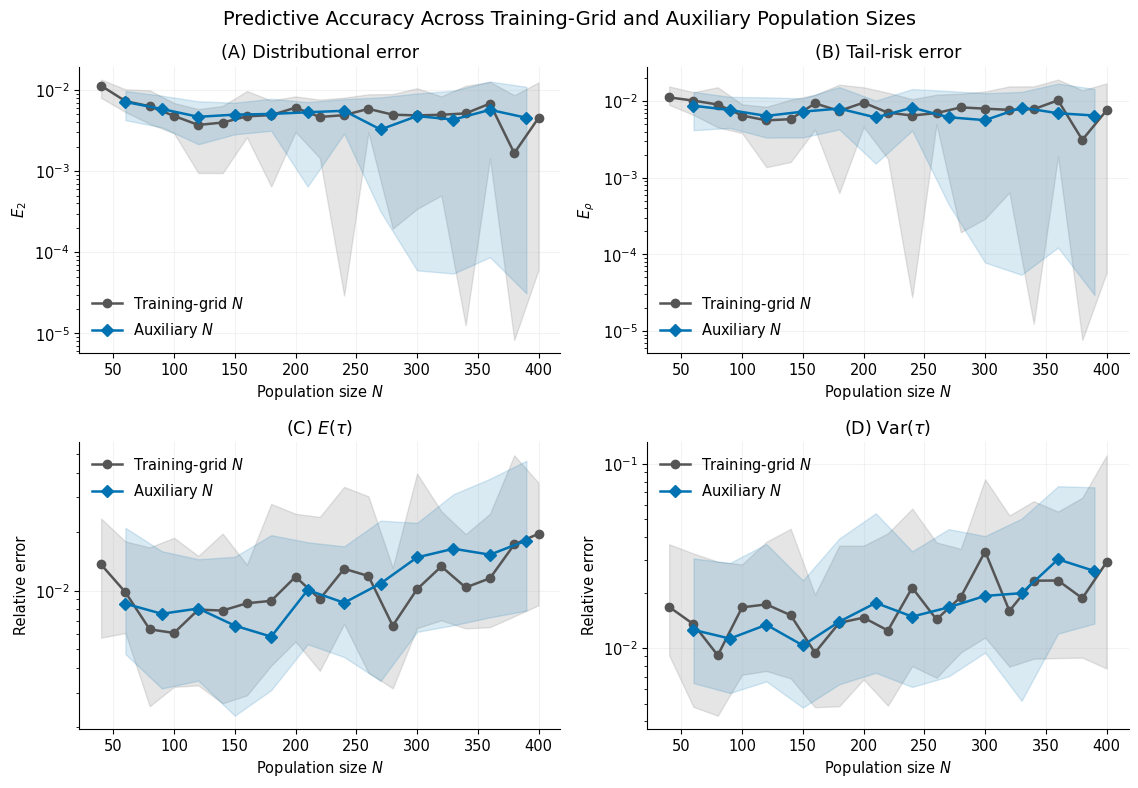


ORIGINAL vs AUGMENTED TEST RESULTS
                 Metric  Old_n  New_n  Old_median  New_median  Old_p95  New_p95  Median_change  P95_change
                     E2    950   2000    0.005107    0.005217 0.017010 0.017408       0.000110    0.000398
                   Erho    950   2000    0.007565    0.007508 0.025289 0.025517      -0.000057    0.000228
                  Eover    950   2000    0.000576    0.000555 0.010164 0.011262      -0.000021    0.001098
                    DKL    950   2000    0.001213    0.001163 0.007363 0.007693      -0.000050    0.000331
  Relative error E(tau)    869   1831    0.009958    0.010106 0.107658 0.107634       0.000148   -0.000024
Relative error Var(tau)    869   1831    0.015533    0.016066 0.200992 0.191972       0.000533   -0.009020

AUGMENTED TEST EVALUATION COMPLETE
Training configurations R = 10,000
Validation configurations = 500 (unchanged)
Training-grid test configurations = 1,000
Auxiliary test configurations = 1,000
Total independent te

In [6]:
# =====================================================================================
# SECTION 5.2 — AUGMENTED INDEPENDENT TEST SET
# Existing model unchanged
# Existing tests retained:
#   seen   = 500
#   interp = 450
# Add:
#   seen   +500  -> total 1000
#   interp +550  -> total 1000
# =====================================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("="*90)
print("AUGMENTING TEST SET ONLY — NO RETRAINING")
print("="*90)

# ---------------------------------------------------------------------
# 1. ADDITIONAL INDEPENDENT TEST CONFIGURATIONS
#    Different seeds from all previous train/val/test designs.
# ---------------------------------------------------------------------

N_ADD_SEEN   = 500
N_ADD_INTERP = 550

SEED_ADD_SEEN   = cfg.seed + 103
SEED_ADD_INTERP = cfg.seed + 104


seen_add = exact_set(
    "TEST_SEEN_AUGMENT_500",
    design(
        N_ADD_SEEN,
        cfg.train_N,          # UNCHANGED
        SEED_ADD_SEEN
    )
)

interp_add = exact_set(
    "TEST_INTERP_AUGMENT_550",
    design(
        N_ADD_INTERP,
        cfg.interp_N,         # UNCHANGED
        SEED_ADD_INTERP
    )
)


# ---------------------------------------------------------------------
# 2. EVALUATE EXISTING FITTED MODEL
# ---------------------------------------------------------------------

SE_ADD = pack(seen_add)
IN_ADD = pack(interp_add)

res_seen_add = evaluate(
    hnet, tnet,
    SE_ADD,
    seen_add
)

res_interp_add = evaluate(
    hnet, tnet,
    IN_ADD,
    interp_add
)


# ---------------------------------------------------------------------
# 3. COMBINE WITH ORIGINAL TEST RESULTS
# ---------------------------------------------------------------------

seen_aug   = seen   + seen_add
interp_aug = interp + interp_add

res_seen_aug = {
    k: np.r_[
        res_seen[k],
        res_seen_add[k]
    ]
    for k in METRICS
}

res_interp_aug = {
    k: np.r_[
        res_interp[k],
        res_interp_add[k]
    ]
    for k in METRICS
}

assert len(seen_aug)   == 1000
assert len(interp_aug) == 1000


# ---------------------------------------------------------------------
# 4. COMPLETE AUGMENTED TEST COLLECTION
# ---------------------------------------------------------------------

complete_aug = {
    k: np.r_[
        res_seen_aug[k],
        res_interp_aug[k]
    ]
    for k in METRICS
}


labels_aug = {
    "E2":"E2",
    "Erho":"Erho",
    "Eover":"Eover",
    "KL":"DKL",
    "mean_tau_rel":"Relative error E(tau)",
    "var_tau_rel":"Relative error Var(tau)"
}


rows = []

for k in METRICS:

    z = stats(
        complete_aug[k]
    )

    rows.append({
        "Metric": labels_aug[k],
        "Median": z["median"],
        "Q1": z["q1"],
        "Q3": z["q3"],
        "P95": z["p95"]
    })


table_aug = pd.DataFrame(rows)

table_aug.to_csv(
    OUT/"table_5_2_augmented_2000_test.csv",
    index=False
)


print("\n"+"="*90)
print("AUGMENTED TEST TABLE — 2,000 CONFIGURATIONS")
print("="*90)

print(
    table_aug.to_string(
        index=False
    )
)


# ---------------------------------------------------------------------
# 5. SPLIT-SPECIFIC SUMMARIES
# ---------------------------------------------------------------------

def split_summary(name,res):

    rows=[]

    for k in METRICS:

        z=stats(
            res[k]
        )

        rows.append({
            "Split":name,
            "Metric":labels_aug[k],
            "n_finite":
                int(
                    np.isfinite(
                        res[k]
                    ).sum()
                ),
            "Median":z["median"],
            "Q1":z["q1"],
            "Q3":z["q3"],
            "P95":z["p95"]
        })

    return rows


split_table = pd.DataFrame(
    split_summary(
        "Training-grid N",
        res_seen_aug
    )
    +
    split_summary(
        "Auxiliary N",
        res_interp_aug
    )
)

split_table.to_csv(
    OUT/"table_5_2_augmented_by_split.csv",
    index=False
)


# ---------------------------------------------------------------------
# 6. BY-N MEDIAN + IQR
# ---------------------------------------------------------------------

byn_aug = pd.DataFrame(
    summarize_by_N(
        seen_aug,
        res_seen_aug,
        "Training-grid"
    )
    +
    summarize_by_N(
        interp_aug,
        res_interp_aug,
        "Auxiliary"
    )
)

byn_aug.to_csv(
    OUT/"accuracy_by_N_augmented_2000_test.csv",
    index=False
)


# ---------------------------------------------------------------------
# 7. UPDATED POPULATION-SIZE FIGURE
# ---------------------------------------------------------------------

fig,axs = plt.subplots(
    2,2,
    figsize=(11.5,8)
)

spec = [
    ("E2",
     r"$E_2$",
     "(A) Distributional error"),

    ("Erho",
     r"$E_\rho$",
     "(B) Tail-risk error"),

    ("mean_tau_rel",
     "Relative error",
     r"(C) $E(\tau)$"),

    ("var_tau_rel",
     "Relative error",
     r"(D) $\mathrm{Var}(\tau)$")
]


for ax,(metric,ylabel,title) in zip(
    axs.flat,
    spec
):

    for split,label,color,marker in (

        (
            "Training-grid",
            "Training-grid $N$",
            "#555555",
            "o"
        ),

        (
            "Auxiliary",
            "Auxiliary $N$",
            "#0072B2",
            "D"
        )
    ):

        z = (
            byn_aug[
                byn_aug.split == split
            ]
            .sort_values("N")
        )

        x   = z.N.to_numpy()
        med = z[f"{metric}_med"].to_numpy()
        q1  = z[f"{metric}_q1"].to_numpy()
        q3  = z[f"{metric}_q3"].to_numpy()

        ax.plot(
            x,
            med,
            marker=marker,
            color=color,
            lw=1.8,
            label=label
        )

        ax.fill_between(
            x,
            q1,
            q3,
            color=color,
            alpha=.15
        )

    ax.set_yscale("log")
    ax.set_xlabel("Population size $N$")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=.15)
    ax.legend(frameon=False)


fig.suptitle(
    "Predictive Accuracy Across Training-Grid and Auxiliary Population Sizes",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    OUT/"figure_5_2_augmented_2000_test.pdf",
    bbox_inches="tight"
)

plt.savefig(
    OUT/"figure_5_2_augmented_2000_test.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ---------------------------------------------------------------------
# 8. TRUE INTERPOLATION DIAGNOSTIC
# ---------------------------------------------------------------------

true_interp_aug = np.array([
    r.N not in cfg.train_N
    for r in interp_aug
])

diag_aug=[]

for name,mask in (

    (
        "auxiliary_represented_N",
        ~true_interp_aug
    ),

    (
        "genuinely_intermediate_N",
        true_interp_aug
    )

):

    row={
        "group":name,
        "n":int(mask.sum())
    }

    for k in METRICS:

        z=stats(
            res_interp_aug[k][mask]
        )

        row[f"{k}_median"]=z["median"]
        row[f"{k}_q1"]=z["q1"]
        row[f"{k}_q3"]=z["q3"]
        row[f"{k}_p95"]=z["p95"]

    diag_aug.append(row)


diag_aug = pd.DataFrame(
    diag_aug
)

diag_aug.to_csv(
    OUT/"true_interpolation_diagnostic_augmented.csv",
    index=False
)


# ---------------------------------------------------------------------
# 9. COMPARE ORIGINAL vs AUGMENTED RESULTS
# ---------------------------------------------------------------------

original_complete = {
    k: np.r_[
        res_seen[k],
        res_interp[k]
    ]
    for k in METRICS
}


comparison=[]

for k in METRICS:

    old=stats(
        original_complete[k]
    )

    new=stats(
        complete_aug[k]
    )

    comparison.append({

        "Metric":labels_aug[k],

        "Old_n":
            int(
                np.isfinite(
                    original_complete[k]
                ).sum()
            ),

        "New_n":
            int(
                np.isfinite(
                    complete_aug[k]
                ).sum()
            ),

        "Old_median":
            old["median"],

        "New_median":
            new["median"],

        "Old_p95":
            old["p95"],

        "New_p95":
            new["p95"],

        "Median_change":
            new["median"]
            -
            old["median"],

        "P95_change":
            new["p95"]
            -
            old["p95"]
    })


comparison = pd.DataFrame(
    comparison
)

comparison.to_csv(
    OUT/"original_vs_augmented_test_comparison.csv",
    index=False
)


print("\n"+"="*90)
print("ORIGINAL vs AUGMENTED TEST RESULTS")
print("="*90)

print(
    comparison.to_string(
        index=False
    )
)


# ---------------------------------------------------------------------
# 10. SAVE EVERYTHING
# ---------------------------------------------------------------------

apickle(
    {
        "seen_aug":seen_aug,
        "interp_aug":interp_aug,

        "res_seen_aug":
            res_seen_aug,

        "res_interp_aug":
            res_interp_aug,

        "complete_aug":
            complete_aug,

        "table_aug":
            table_aug,

        "split_table":
            split_table,

        "by_N":
            byn_aug,

        "true_interp_diag":
            diag_aug,

        "comparison":
            comparison,

        "n_seen":
            len(seen_aug),

        "n_interp":
            len(interp_aug)
    },
    OUT/"section_5_2_augmented_test_results.pkl"
)


print("\n"+"="*90)
print("AUGMENTED TEST EVALUATION COMPLETE")
print("="*90)

print(
    f"Training configurations R = {cfg.n_train:,}"
)

print(
    f"Validation configurations = {cfg.n_val:,} "
    "(unchanged)"
)

print(
    f"Training-grid test configurations = {len(seen_aug):,}"
)

print(
    f"Auxiliary test configurations = {len(interp_aug):,}"
)

print(
    f"Total independent test configurations = "
    f"{len(seen_aug)+len(interp_aug):,}"
)

print("\nSaved:")
print(
    OUT/"table_5_2_augmented_2000_test.csv"
)

print(
    OUT/"figure_5_2_augmented_2000_test.pdf"
)

print(
    OUT/"true_interpolation_diagnostic_augmented.csv"
)

print(
    OUT/"original_vs_augmented_test_comparison.csv"
)

print("="*90)